In [40]:
import paarti.utils.maos_utils as mu
import paarti.utils.koa_utils as ku
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn

### **Pull MAOS and On-Sky Data**

In [2]:
# CSV Path object
csv = Path('/Users/bdigia/work/ao/keck/maos/keck/my_base/test_csv.csv')
# Root of directory where sky files live
onskyroot = Path("/Users/bdigia/work/ao/airopa_input/")

In [ ]:
basedir = Path("/Users/bdigia/work/ao/keck/maos/keck/my_base") 
# Simulation seeds
seeds = np.array([1, 1000, 5000, 10000])
all_modes = mu.fetch_sky_frames(seeds, onskyroot, basedir, 
                                'piston', 'psd+ncpa-seen', 'psd+ncpa-unseen', 
                                dates=None, update_maos=False, savecsvto='run_maos_data_20241112.csv')

In [2]:
df = pd.read_csv('run_maos_data_20241112.csv')

In [3]:
df

,frames,dates,mjd,telem_status,expstarts,expstops,airmasses,frieds,tau0,theta0,...,totmaoswfe-piston,totmaoswfe-psd+ncpa-seen,totmaoswfe-psd+ncpa-unseen,homaoswfe-piston,homaoswfe-psd+ncpa-seen,homaoswfe-psd+ncpa-unseen,ttmaoswfe-piston,ttmaoswfe-psd+ncpa-seen,ttmaoswfe-psd+ncpa-unseen,DM_fitting_errors
0,c0120,20100815,55423.31508,False,07:33:43.032,07:34:26.142,1.58257,0.388730,0.026257,1.778738,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,600.312699
1,c0122,20100815,55423.31624,False,07:35:22.783,07:36:05.908,1.58649,0.388730,0.028705,1.646621,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,600.312699
2,c0123,20100815,55423.31695,False,07:36:24.268,07:37:07.095,1.58896,0.273162,0.027589,1.642093,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,805.504265
3,c0124,20100815,55423.31752,False,07:37:13.618,07:37:56.758,1.59099,0.273162,0.027589,1.638742,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,805.504265
4,c0008,20100815,55423.24293,False,05:49:49.016,05:50:32.269,1.55171,0.206265,0.022976,2.528482,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1017.957877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,c2058,20170823,57988.27088,True,06:30:04.473,06:30:46.948,1.53049,0.174258,0.007300,2.175719,...,338.149631,411.931457,392.466074,257.286994,327.012331,301.832617,219.316196,250.419031,250.735050,1171.538060
164,c2059,20170823,57988.27147,True,06:30:55.243,06:31:37.718,1.53144,0.174258,0.007007,2.173560,...,349.331727,420.139810,402.334684,269.731738,337.077275,312.962779,221.641904,250.602761,252.621760,1171.538060
165,c2060,20170823,57988.27206,True,06:31:46.012,06:32:28.494,1.53237,0.138452,0.005465,1.706254,...,442.346364,501.505583,486.169109,353.524727,408.938452,388.218709,265.001240,289.710169,291.920974,1419.064463
166,c2061,20170823,57988.27265,True,06:32:36.882,06:33:19.357,1.53333,0.138452,0.005605,1.827725,...,440.506125,499.715701,485.908285,352.302865,407.595747,387.459821,264.023723,288.663483,292.846401,1419.064463


In [4]:
all_modes = df

#### **Display ``all_modes`` keys**

In [4]:
all_modes.keys()

Index(['frames', 'dates', 'mjd', 'telem_status', 'expstarts', 'expstops',
       'airmasses', 'frieds', 'tau0', 'theta0', 'dimms', 'dimmtimes', 'masses',
       'masstimes', 'masswts0', 'masswts500', 'masswts1000', 'masswts2000',
       'masswts4000', 'masswts8000', 'masswts16000', 'windspds', 'winddirs',
       'temps', 'skystrehls', 'maosstrehls-piston',
       'maosstrehls-psd+ncpa-seen', 'maosstrehls-psd+ncpa-unseen',
       'maos_stds_strehls-piston', 'maos_stds_strehls-psd+ncpa-seen',
       'maos_stds_strehls-psd+ncpa-unseen', 'skyfwhms', 'skyempfwhms',
       'maosfwhms-piston', 'maosfwhms-psd+ncpa-seen',
       'maosfwhms-psd+ncpa-unseen', 'maosempfwhms-piston',
       'maosempfwhms-psd+ncpa-seen', 'maosempfwhms-psd+ncpa-unseen',
       'maos_stds_fwhms-piston', 'maos_stds_fwhms-psd+ncpa-seen',
       'maos_stds_fwhms-psd+ncpa-unseen', 'maos_stds_emp_fwhms-piston',
       'maos_stds_emp_fwhms-psd+ncpa-seen',
       'maos_stds_emp_fwhms-psd+ncpa-unseen', 'lbwfsfwhms', 'skyrmswf

#### **Add in telemetry simulations**

Currently a different naming convention so ``fetch_sky_frames`` isn't looking for the telemetry simulation results

In [6]:
folders = ["A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed10000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed1000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed1_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed5000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed10000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed1000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed1_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed5000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed10000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed1000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed1_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed5000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed10000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed1000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed1_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed5000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0062_c2062_seed10000_epoch20170823/"]

frames = ["n0058", "n0059", 'n0060', 'n0061', 'n0062']
basedir = Path("/Users/bdigia/work/ao/keck/maos/keck/my_base")

/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed1_epoch20170823/evlpsfcl_1_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Scale = 0.0200277 arcsec/px
FWHM on iteration 1 = 50.57 mas | Empirical FWHM on iteration 1 = 59.79 mas
[128.288 127.909]
Filter = Kp | Scale (arcsec/px) = 0.009952 | Wavelength (microns) = 2.124500 


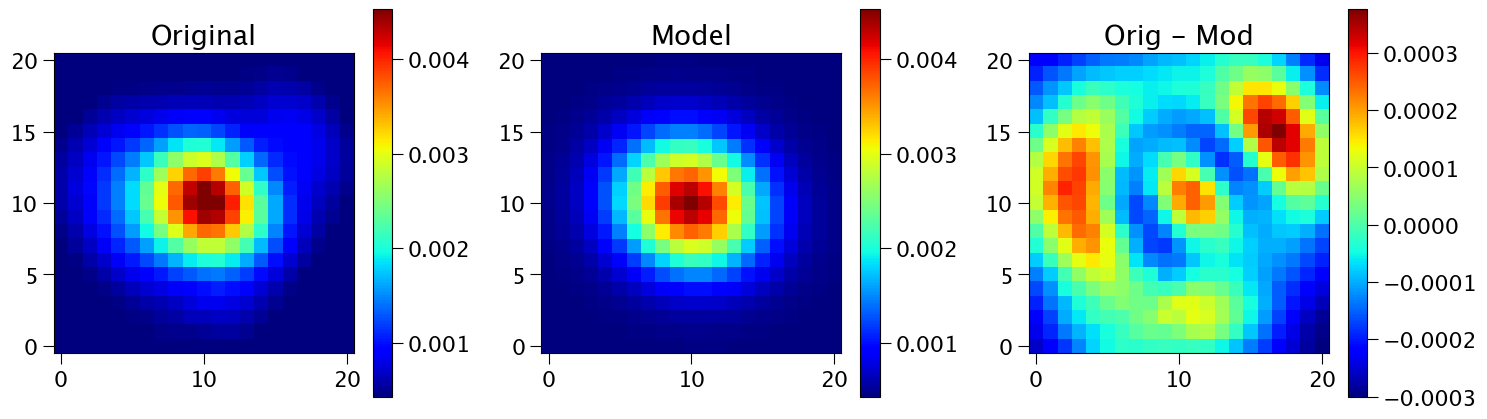

peak flux ratio =  0.004716151  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2058_psf.fits   0.128   484.6   74.84  149.9  150.0

c2058_psf.fits                   0.128   484.6   74.84  57988.2709

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed1_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1701.7        886.6       1452.4
Closed           396.0        329.2        220.0

Pos  0 
-------  
Open            1701.7        886.6       1452.4
Closed           396.0        329.2        220.0
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed1000_epoch20170823/evlpsfcl_1000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Scale

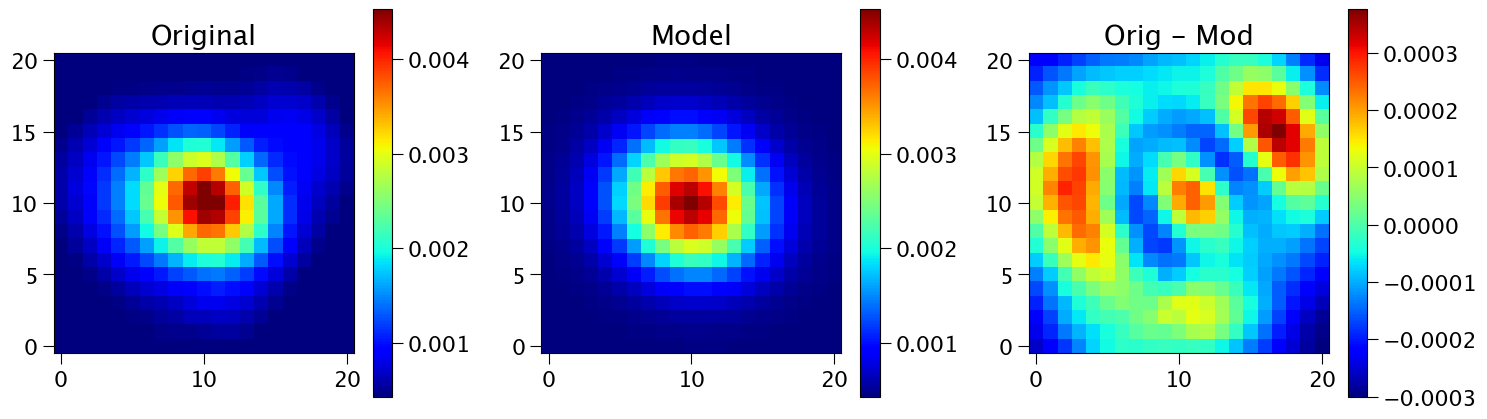

peak flux ratio =  0.004716151  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2058_psf.fits   0.128   484.6   74.84  149.9  150.0

c2058_psf.fits                   0.128   484.6   74.84  57988.2709

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed1000_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1624.3        827.0       1397.9
Closed           386.1        309.0        231.6

Pos  0 
-------  
Open            1624.3        827.0       1397.9
Closed           386.1        309.0        231.6
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed5000_epoch20170823/evlpsfcl_5000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Sc

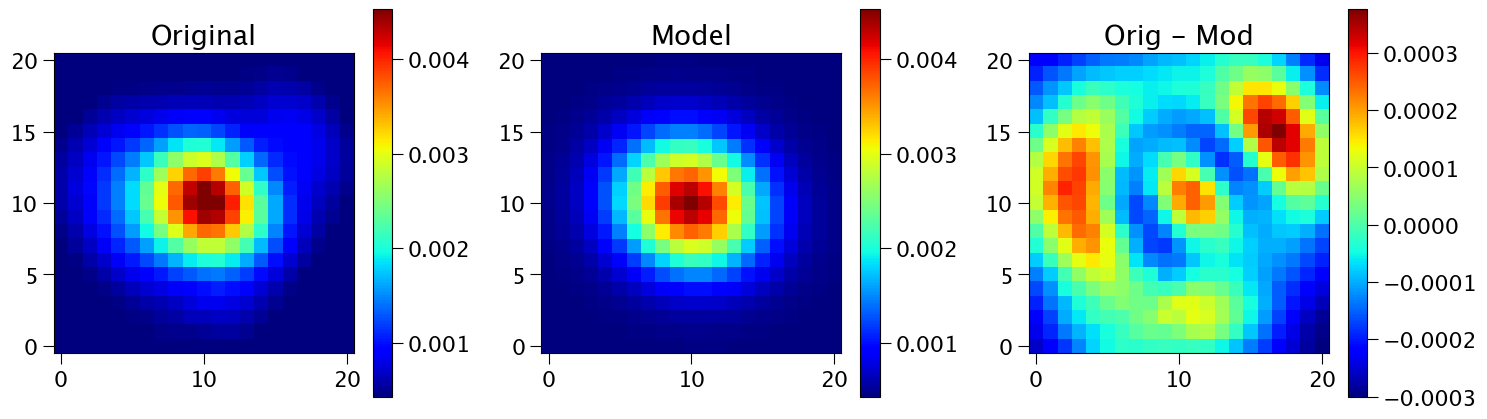

peak flux ratio =  0.004716151  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2058_psf.fits   0.128   484.6   74.84  149.9  150.0

c2058_psf.fits                   0.128   484.6   74.84  57988.2709

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed5000_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1602.5        892.7       1330.8
Closed           406.0        323.4        245.4

Pos  0 
-------  
Open            1602.5        892.7       1330.8
Closed           406.0        323.4        245.4
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed10000_epoch20170823/evlpsfcl_10000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | 

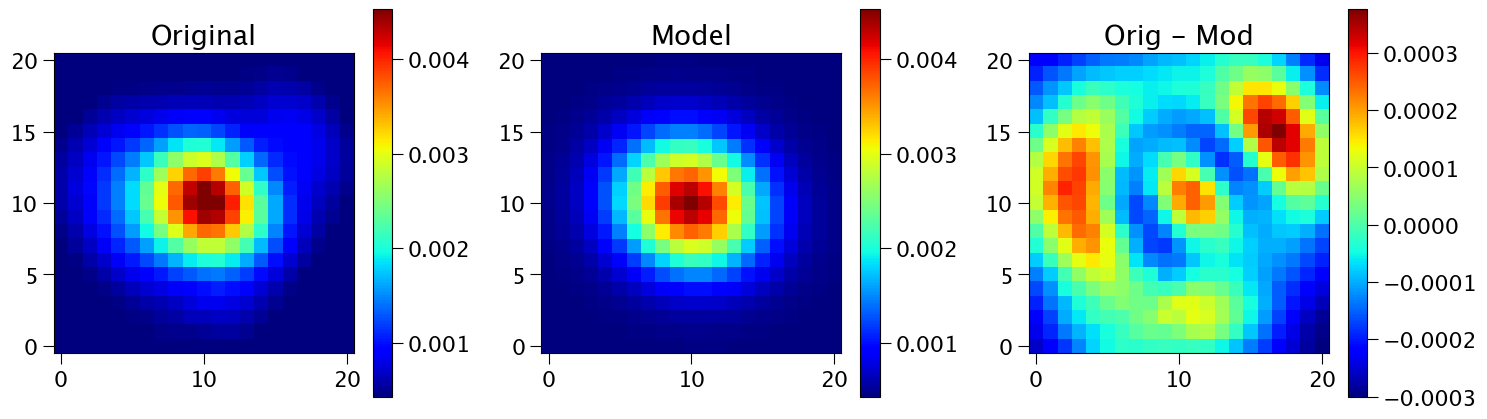

peak flux ratio =  0.004716151  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2058_psf.fits   0.128   484.6   74.84  149.9  150.0

c2058_psf.fits                   0.128   484.6   74.84  57988.2709

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed10000_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1462.5        873.6       1173.0
Closed           396.1        310.6        245.9

Pos  0 
-------  
Open            1462.5        873.6       1173.0
Closed           396.1        310.6        245.9
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed1_epoch20170823/evlpsfcl_1_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Scale =

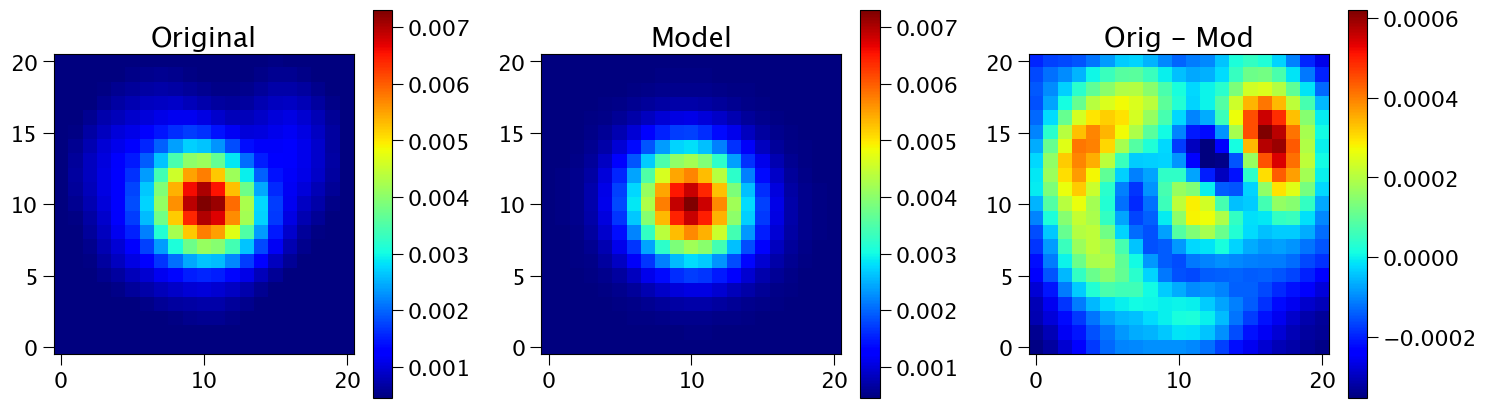

peak flux ratio =  0.0075078555  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2059_psf.fits   0.204   426.2   64.37  150.0  150.0

c2059_psf.fits                   0.204   426.2   64.37  57988.2715

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed1_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1953.2        908.0       1729.3
Closed           397.0        329.0        222.2

Pos  0 
-------  
Open            1953.2        908.0       1729.3
Closed           397.0        329.0        222.2
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed1000_epoch20170823/evlpsfcl_1000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Scal

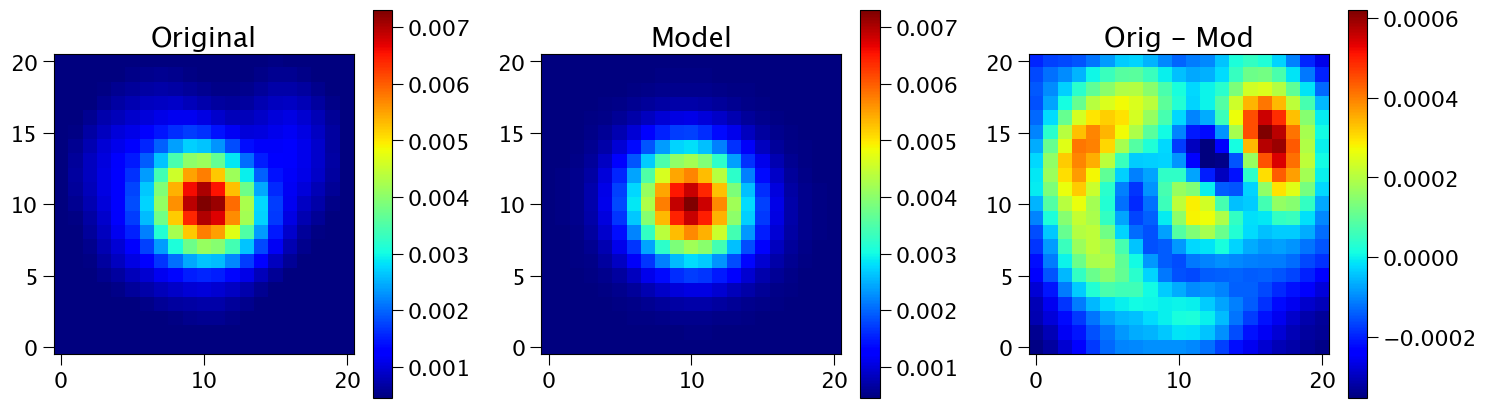

peak flux ratio =  0.0075078555  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2059_psf.fits   0.204   426.2   64.37  150.0  150.0

c2059_psf.fits                   0.204   426.2   64.37  57988.2715

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed1000_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1517.4        836.8       1265.8
Closed           386.5        310.5        230.2

Pos  0 
-------  
Open            1517.4        836.8       1265.8
Closed           386.5        310.5        230.2
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed5000_epoch20170823/evlpsfcl_5000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | S

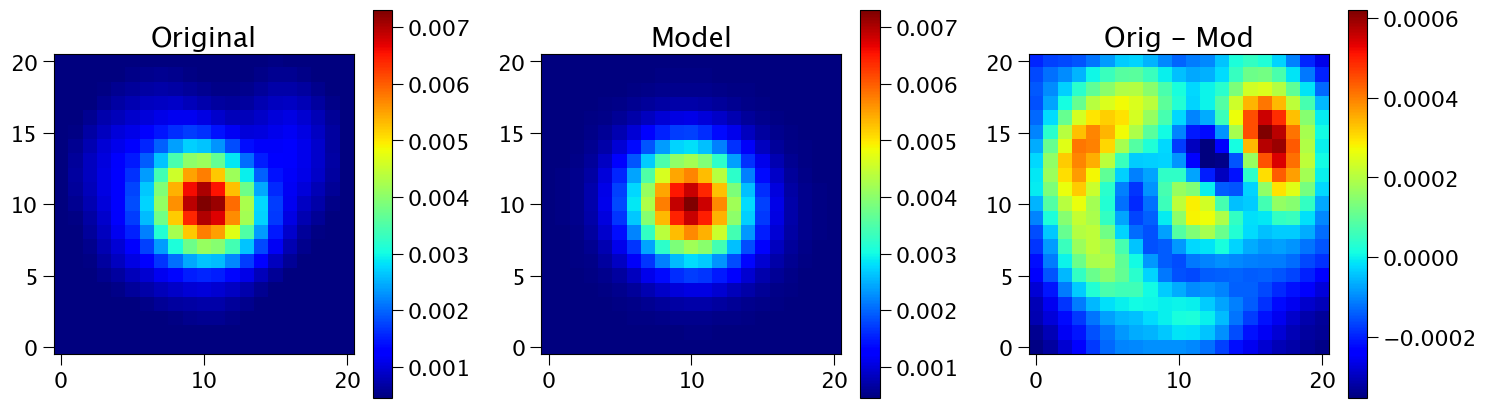

peak flux ratio =  0.0075078555  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2059_psf.fits   0.204   426.2   64.37  150.0  150.0

c2059_psf.fits                   0.204   426.2   64.37  57988.2715

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed5000_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1233.2        996.6        726.4
Closed           413.4        330.1        248.8

Pos  0 
-------  
Open            1233.2        996.6        726.4
Closed           413.4        330.1        248.8
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed10000_epoch20170823/evlpsfcl_10000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 |

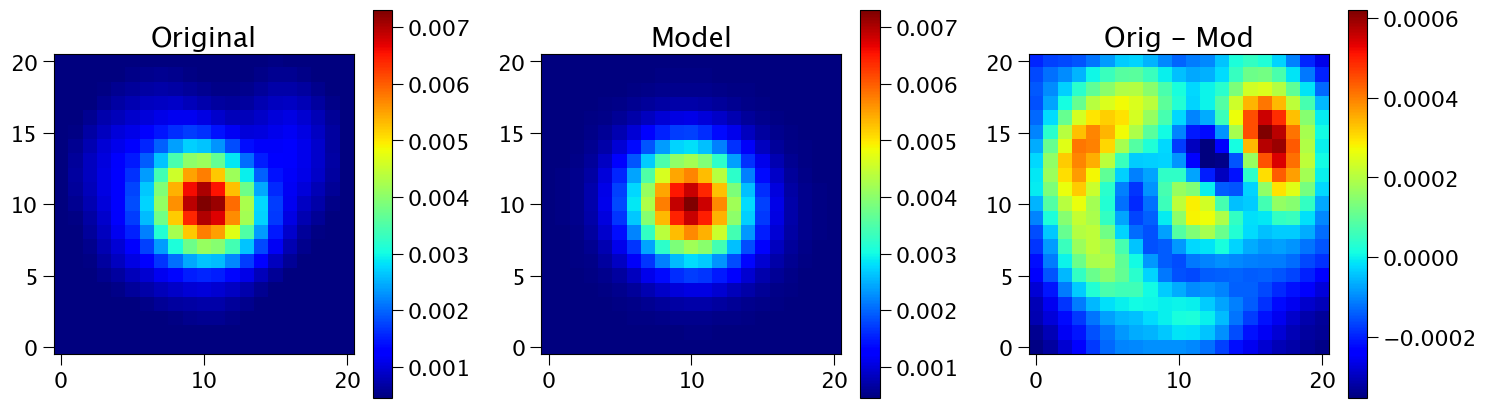

peak flux ratio =  0.0075078555  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2059_psf.fits   0.204   426.2   64.37  150.0  150.0

c2059_psf.fits                   0.204   426.2   64.37  57988.2715

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed10000_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1473.6       1016.4       1066.9
Closed           405.1        323.0        244.5

Pos  0 
-------  
Open            1473.6       1016.4       1066.9
Closed           405.1        323.0        244.5
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed1_epoch20170823/evlpsfcl_1_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Scale 

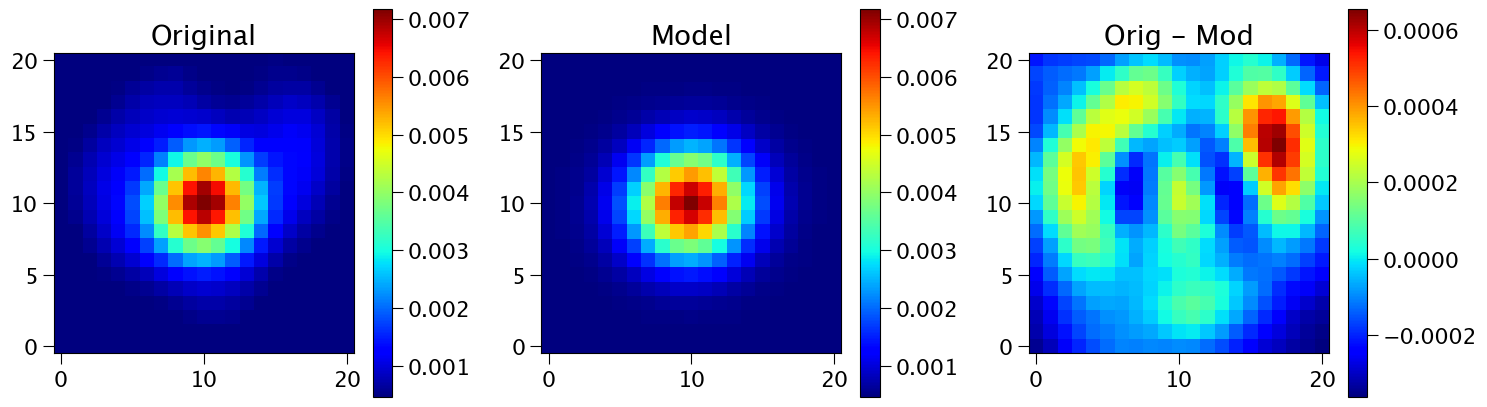

peak flux ratio =  0.007402367  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2060_psf.fits   0.201   428.1   62.95  150.0  150.0

c2060_psf.fits                   0.201   428.1   62.95  57988.2721

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed1_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            2167.0       1264.9       1759.5
Closed           533.8        463.2        265.4

Pos  0 
-------  
Open            2167.0       1264.9       1759.5
Closed           533.8        463.2        265.4
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed1000_epoch20170823/evlpsfcl_1000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Scale

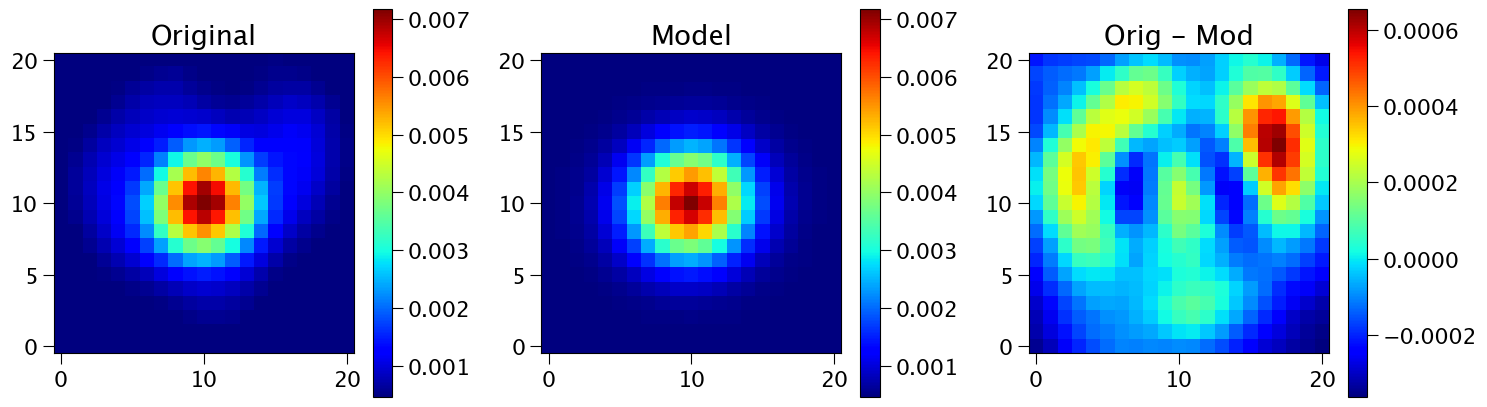

peak flux ratio =  0.007402367  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2060_psf.fits   0.201   428.1   62.95  150.0  150.0

c2060_psf.fits                   0.201   428.1   62.95  57988.2721

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed1000_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1891.9        968.6       1625.1
Closed           438.2        349.7        264.1

Pos  0 
-------  
Open            1891.9        968.6       1625.1
Closed           438.2        349.7        264.1
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed5000_epoch20170823/evlpsfcl_5000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Sc

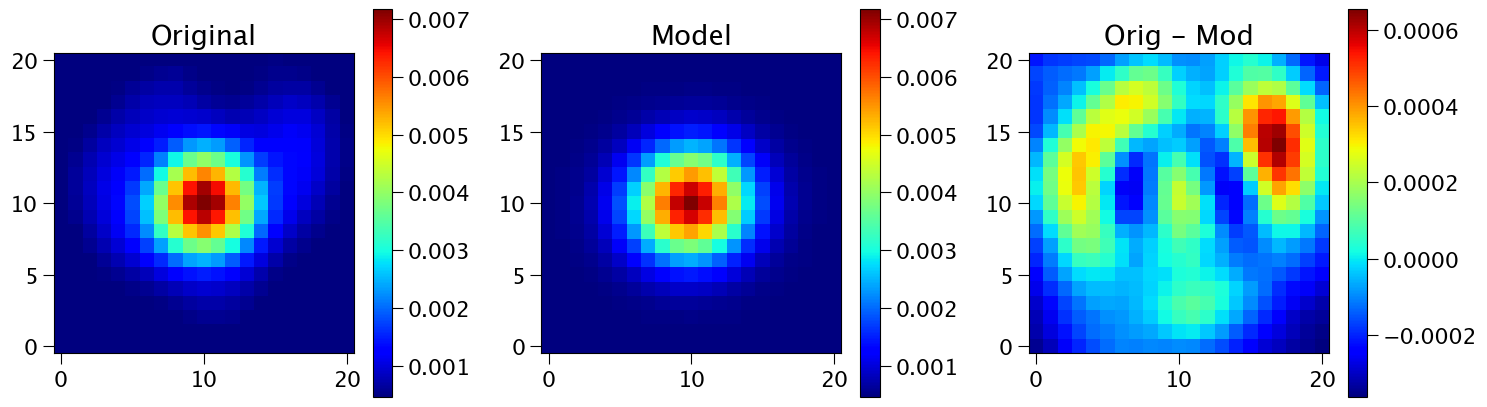

peak flux ratio =  0.007402367  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2060_psf.fits   0.201   428.1   62.95  150.0  150.0

c2060_psf.fits                   0.201   428.1   62.95  57988.2721

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed5000_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1341.0       1127.3        726.1
Closed           472.8        393.2        262.6

Pos  0 
-------  
Open            1341.0       1127.3        726.1
Closed           472.8        393.2        262.6
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed10000_epoch20170823/evlpsfcl_10000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | 

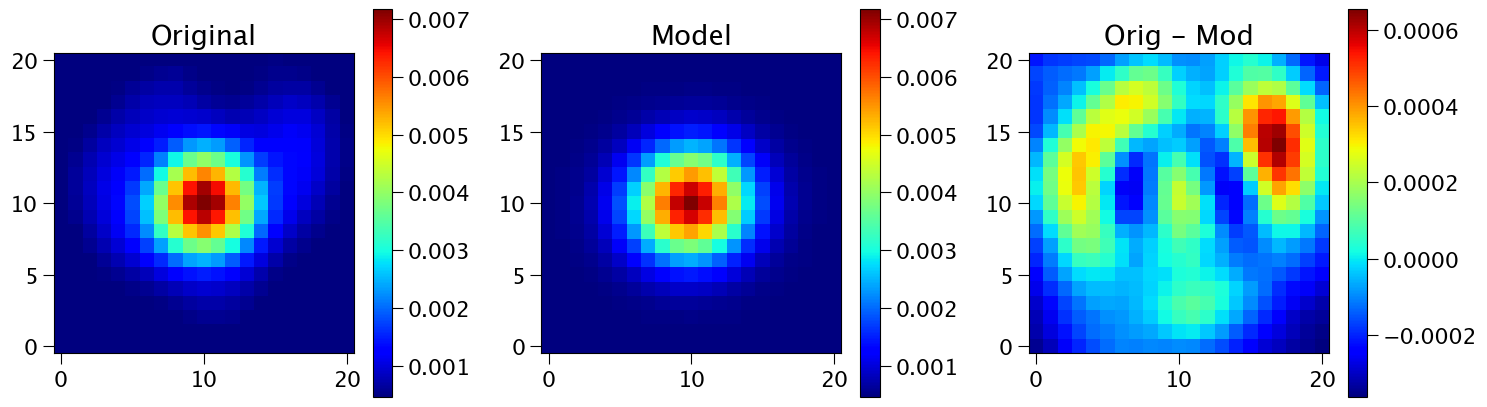

peak flux ratio =  0.007402367  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2060_psf.fits   0.201   428.1   62.95  150.0  150.0

c2060_psf.fits                   0.201   428.1   62.95  57988.2721

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed10000_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1902.8       1142.3       1521.8
Closed           476.3        374.6        294.2

Pos  0 
-------  
Open            1902.8       1142.3       1521.8
Closed           476.3        374.6        294.2
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed1_epoch20170823/evlpsfcl_1_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Scale =

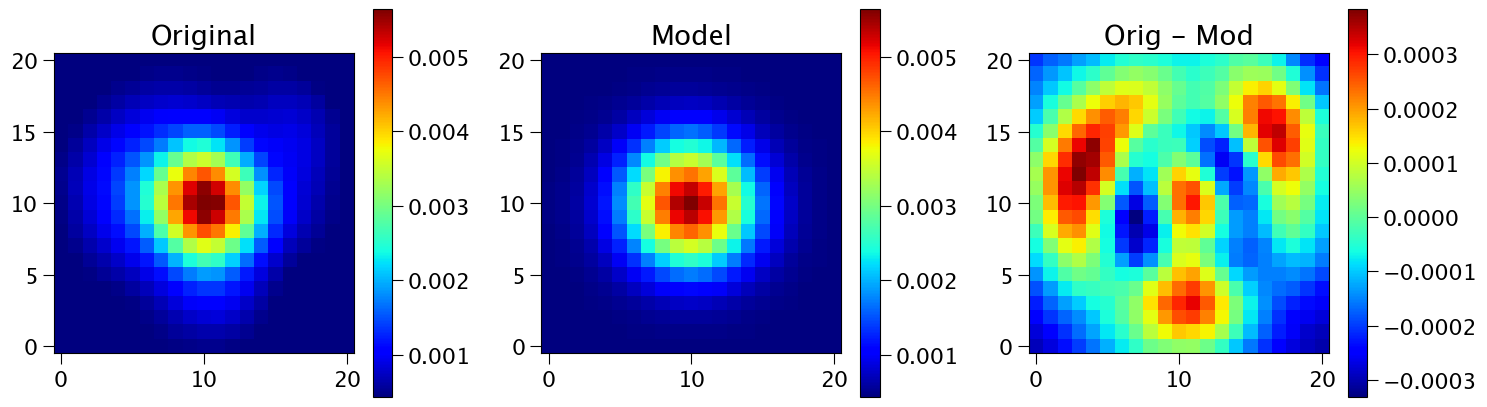

peak flux ratio =  0.0058663366  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2061_psf.fits   0.160   458.1   69.98  149.9  150.0

c2061_psf.fits                   0.160   458.1   69.98  57988.2726

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed1_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            2327.7       1189.0       2001.1
Closed           498.1        431.2        249.4

Pos  0 
-------  
Open            2327.7       1189.0       2001.1
Closed           498.1        431.2        249.4
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed1000_epoch20170823/evlpsfcl_1000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Scal

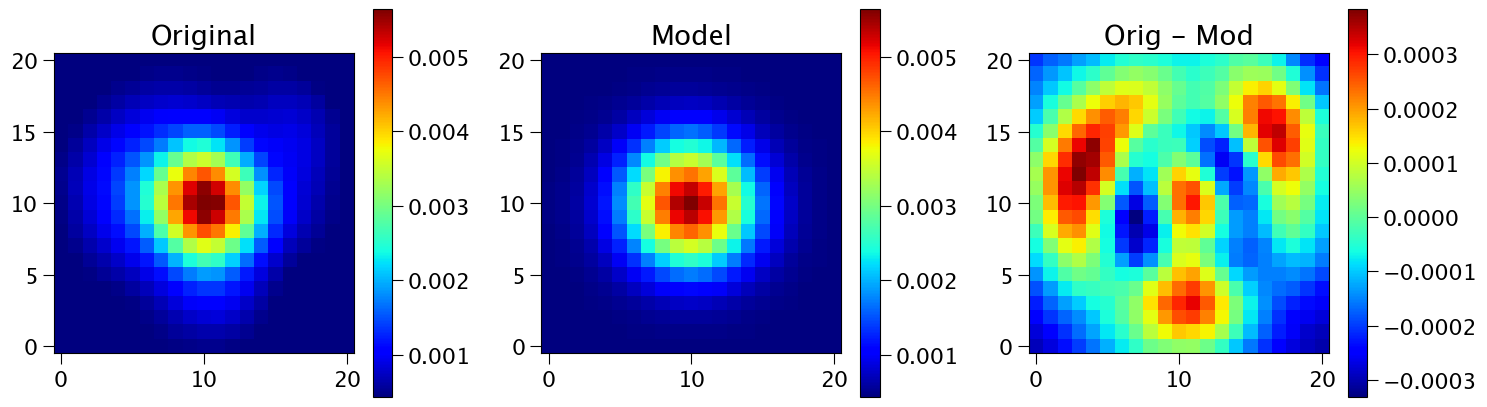

peak flux ratio =  0.0058663366  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2061_psf.fits   0.160   458.1   69.98  149.9  150.0

c2061_psf.fits                   0.160   458.1   69.98  57988.2726

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed1000_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1686.0       1017.1       1344.6
Closed           439.2        355.2        258.4

Pos  0 
-------  
Open            1686.0       1017.1       1344.6
Closed           439.2        355.2        258.4
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed5000_epoch20170823/evlpsfcl_5000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | S

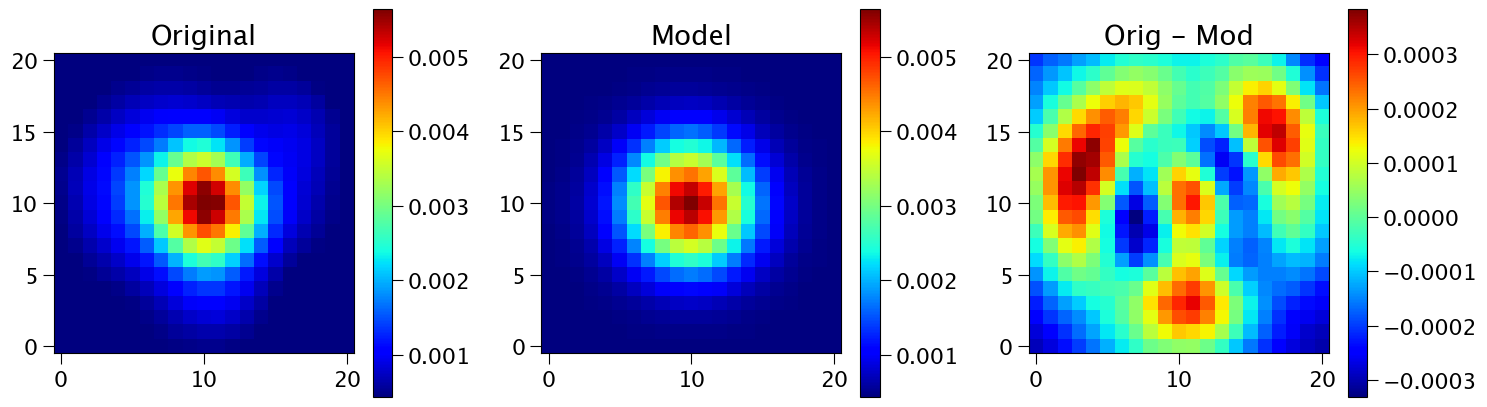

peak flux ratio =  0.0058663366  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2061_psf.fits   0.160   458.1   69.98  149.9  150.0

c2061_psf.fits                   0.160   458.1   69.98  57988.2726

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed5000_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1592.5       1158.6       1092.6
Closed           479.9        395.1        272.3

Pos  0 
-------  
Open            1592.5       1158.6       1092.6
Closed           479.9        395.1        272.3
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed10000_epoch20170823/evlpsfcl_10000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 |

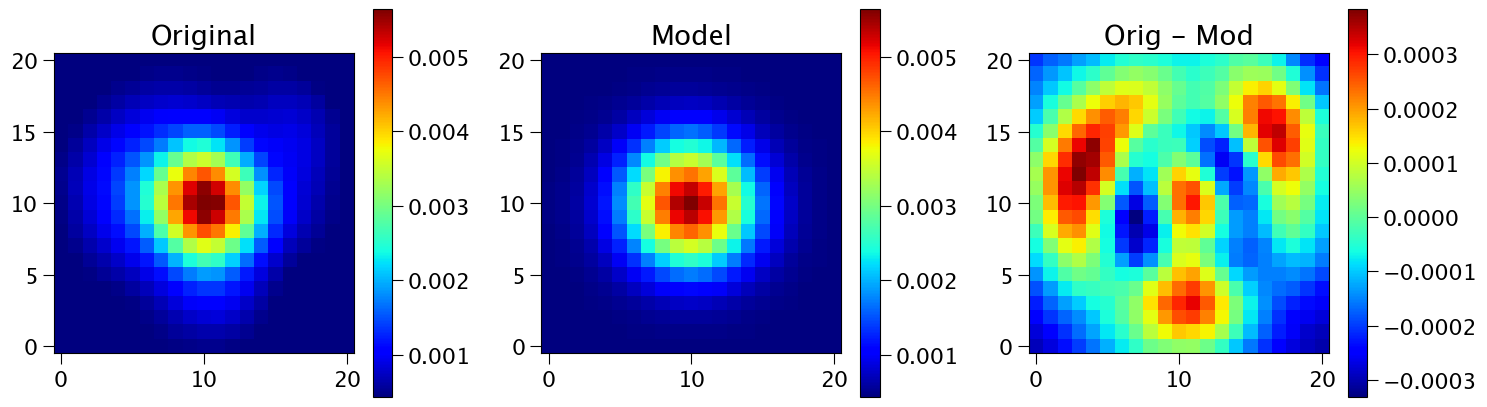

peak flux ratio =  0.0058663366  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2061_psf.fits   0.160   458.1   69.98  149.9  150.0

c2061_psf.fits                   0.160   458.1   69.98  57988.2726

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed10000_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1809.8       1165.7       1384.4
Closed           474.7        385.9        276.4

Pos  0 
-------  
Open            1809.8       1165.7       1384.4
Closed           474.7        385.9        276.4
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0062_c2062_seed1_epoch20170823/evlpsfcl_1_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Scale 

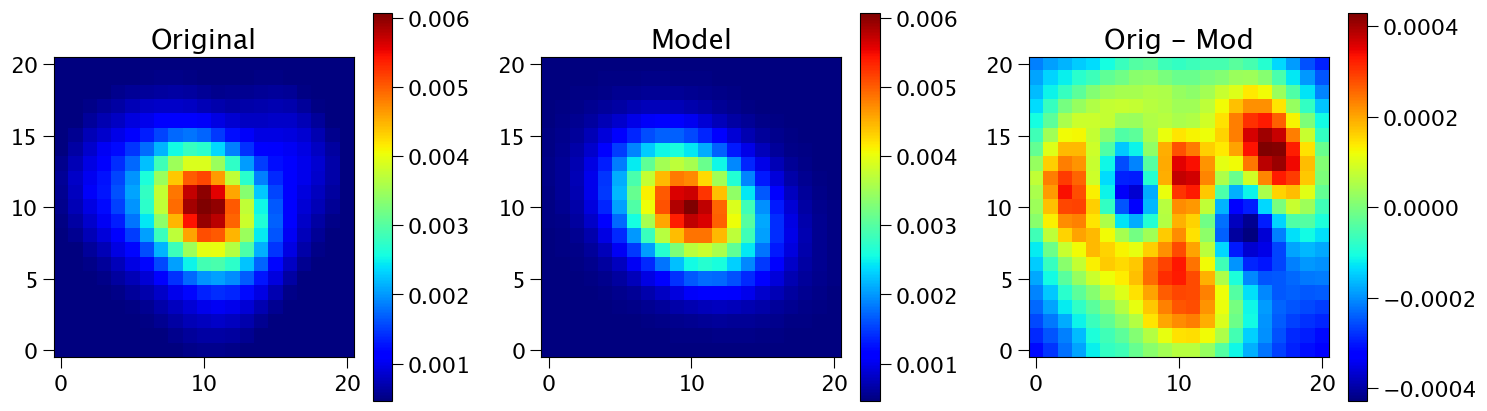

peak flux ratio =  0.0062862253  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2062_psf.fits   0.171   449.4   71.28  149.9  150.0

c2062_psf.fits                   0.171   449.4   71.28  57988.2732

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0062_c2062_seed1_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1934.4        973.1       1671.8
Closed           422.4        351.7        233.9

Pos  0 
-------  
Open            1934.4        973.1       1671.8
Closed           422.4        351.7        233.9
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0062_c2062_seed1000_epoch20170823/evlpsfcl_1000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Scal

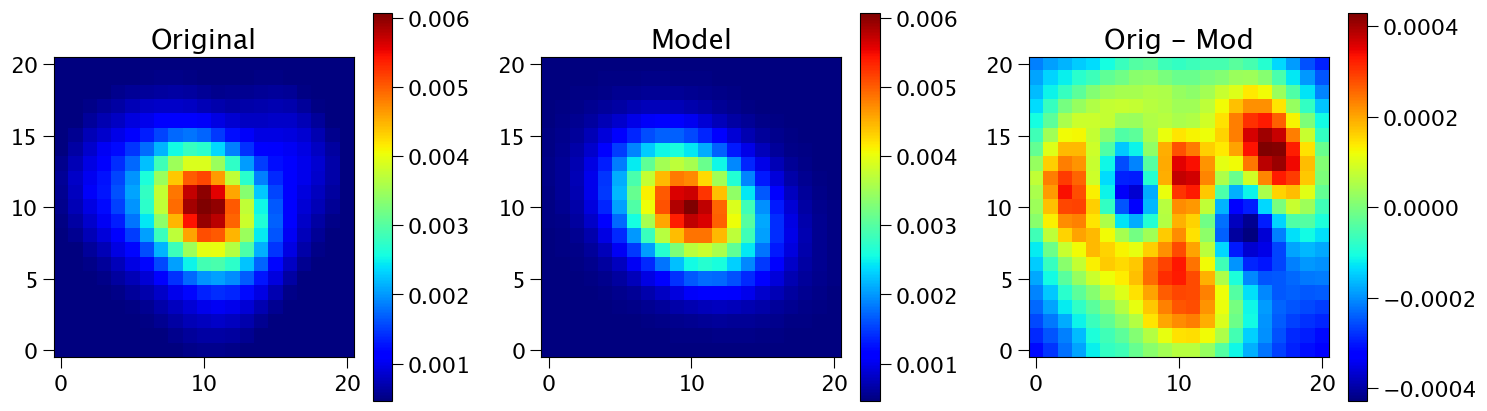

peak flux ratio =  0.0062862253  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2062_psf.fits   0.171   449.4   71.28  149.9  150.0

c2062_psf.fits                   0.171   449.4   71.28  57988.2732

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0062_c2062_seed1000_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1304.5        861.9        979.2
Closed           400.4        312.5        250.3

Pos  0 
-------  
Open            1304.5        861.9        979.2
Closed           400.4        312.5        250.3
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0062_c2062_seed5000_epoch20170823/evlpsfcl_5000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | S

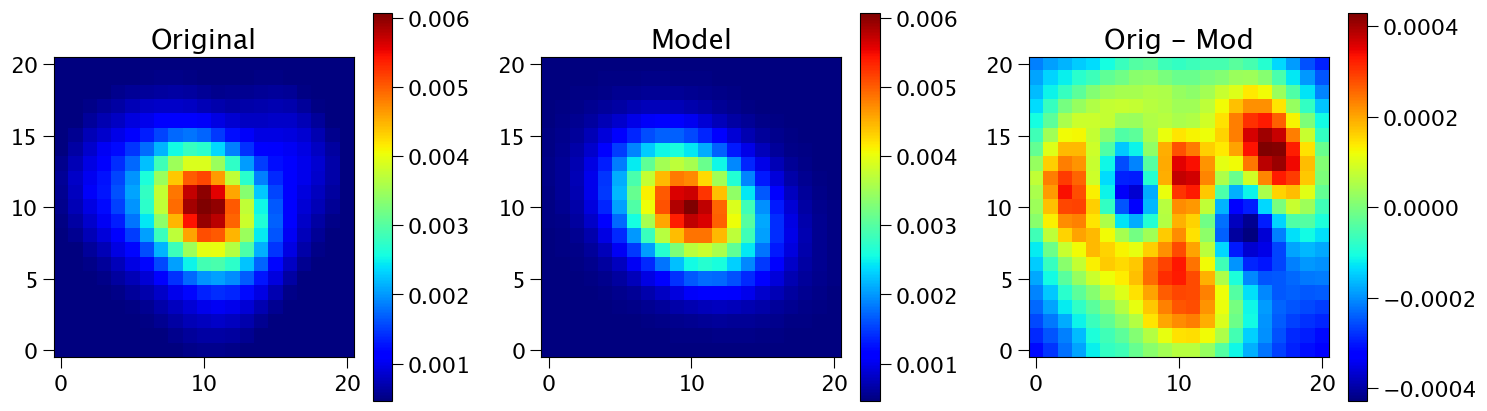

peak flux ratio =  0.0062862253  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2062_psf.fits   0.171   449.4   71.28  149.9  150.0

c2062_psf.fits                   0.171   449.4   71.28  57988.2732

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0062_c2062_seed5000_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1369.5        951.0        985.4
Closed           419.5        329.7        259.4

Pos  0 
-------  
Open            1369.5        951.0        985.4
Closed           419.5        329.7        259.4
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0062_c2062_seed10000_epoch20170823/evlpsfcl_10000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 |

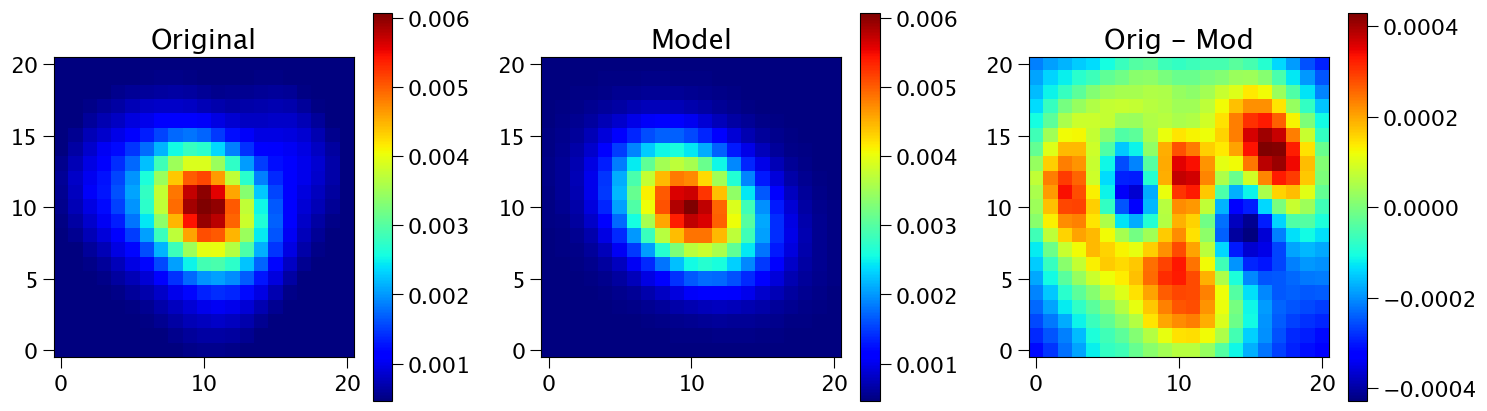

peak flux ratio =  0.0062862253  dl peak flux ratio =  0.036778376
/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2062_psf.fits   0.171   449.4   71.28  149.9  150.0

c2062_psf.fits                   0.171   449.4   71.28  57988.2732

Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0062_c2062_seed10000_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1446.4        968.5       1074.2
Closed           411.7        325.4        252.2

Pos  0 
-------  
Open            1446.4        968.5       1074.2
Closed           411.7        325.4        252.2


In [7]:
strehls = []
strehl_stds = []
fwhms = []
fwhm_stds = []
emp_fwhms = []
emp_fwhm_stds = []
rmswfes = []
rmswfe_stds = []
tot_maos_wfes = []
ho_maos_wfes = []
tt_maos_wfes = []
seeds = np.array([1, 1000, 5000, 10000])
sky_sr = []
sky_fwhm = []
sky_rmswfe = []
sky_empfwhm = []
for i, frame in enumerate(frames):
    for seed in seeds:
        dir = basedir.as_posix() + f"/A_keck_scao_lgs_gc_telemetry_input_comp_{frame}_c2{frame[2:]}_seed{seed}_epoch20170823/"
        skydir = [f"/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2{frame[2:]}_psf.fits"]
        strehls_to_avg = []
        fwhms_to_avg = []
        emp_fwhms_to_avg = []
        rmswfes_to_avg = []
        tot_maos_to_avg = []
        ho_maos_to_avg = []
        tt_maos_to_avg = []
        # out_file = f"maos_comp_{framedates[i][0]}_epoch{framedates[i][1]}_seed{seed}_metrics.txt"
        out_file = "temp.txt"
        try:
            maos_seed_strehls, maos_seed_fwhms, maos_seed_rmswfes, maos_seed_emp_fwhms = mu.calc_strehl(dir, out_file, sim_seed=seed, apersize=0.6) # 0.6 arcsec aperture size from spot check analysis
            sky_strehls, sky_fwhms, sky_rmswfes, sky_empfwhms = mu.calc_strehl_on_sky(skydir, "temp.txt")
            _, maos_cl_metrics, _, _ = mu.print_wfe_metrics(directory=dir, seed=seed)
            tot_maos_err = maos_cl_metrics[0]
            tt_maos_err = maos_cl_metrics[1]
            ho_maos_err = maos_cl_metrics[2]
        except Exception as error:
            print(f"Error calculating metrics: {error} --> using NaN for metrics")
            maos_seed_strehls = [np.nan]
            maos_seed_fwhms = [np.nan]
            maos_seed_rmswfes = [np.nan]
            maos_seed_emp_fwhms = [np.nan]
            tot_maos_err = np.nan
            tt_maos_err = np.nan
            ho_maos_err = np.nan
            
        # Store values at 2.12 microns (last values)
        strehls_to_avg.append(maos_seed_strehls[-1])
        fwhms_to_avg.append(maos_seed_fwhms[-1])
        emp_fwhms_to_avg.append(maos_seed_emp_fwhms[-1])
        rmswfes_to_avg.append(maos_seed_rmswfes[-1])
        tot_maos_to_avg.append(tot_maos_err)
        ho_maos_to_avg.append(ho_maos_err)
        tt_maos_to_avg.append(tt_maos_err)
    strehls.append(np.mean(strehls_to_avg))
    strehl_stds.append(np.std(strehls_to_avg))
    fwhms.append(np.mean(fwhms_to_avg))
    fwhm_stds.append(np.std(fwhms_to_avg))
    emp_fwhms.append(np.mean(emp_fwhms_to_avg))
    emp_fwhm_stds.append(np.std(emp_fwhms_to_avg))
    rmswfes.append(np.mean(rmswfes_to_avg))
    rmswfe_stds.append(np.std(rmswfes_to_avg))
    tot_maos_wfes.append(np.mean(tot_maos_to_avg))
    ho_maos_wfes.append(np.mean(ho_maos_to_avg))
    tt_maos_wfes.append(np.mean(tt_maos_to_avg))
    sky_sr.append(sky_strehls)
    sky_fwhm.append(sky_fwhms)
    sky_rmswfe.append(sky_rmswfes)
    sky_empfwhm.append(sky_empfwhms)

### **MAOS vs. On-Sky**

In [8]:
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
%matplotlib inline

In [9]:
just_strehls = np.concatenate((all_modes['maosstrehls-psd+ncpa-seen'].astype(float), strehls))
just_fwhms = np.concatenate((all_modes['maosfwhms-psd+ncpa-seen'].astype(float), fwhms))
just_emp_fwhms = np.concatenate((all_modes['maosempfwhms-psd+ncpa-seen'].astype(float), fwhms))
just_rmswfes = np.concatenate((all_modes['maosrmswfes-psd+ncpa-seen'].astype(float), rmswfes))
just_skysr = np.concatenate((all_modes['skystrehls'].astype(float), np.array(sky_sr).flatten()))
just_skyfwhm = np.concatenate((all_modes['skyfwhms'].astype(float), np.array(sky_fwhm).flatten()))
just_skyrmswfe = np.concatenate((all_modes['skyrmswfes'].astype(float), np.array(sky_rmswfe).flatten()))
dates = np.concatenate((all_modes['dates'], np.full((len(frames)), '20170823')))

In [10]:
out = np.column_stack((all_modes['dates'], 
                       all_modes['maosstrehls-piston'].astype(float), 
                       all_modes['maosfwhms-piston'].astype(float), 
                       all_modes['maosrmswfes-piston'].astype(float), 
                       all_modes['skystrehls'].astype(float), 
                       all_modes['skyfwhms'].astype(float), 
                       all_modes['skyrmswfes'].astype(float)))
col_list = ['dates', 'maosstrehls-piston', 'maosfwhms-piston', 
            'maosrmswfes-piston', 'skystrehls', 'skyfwhms', 'skyrmswfes']
piston_metrics = pd.DataFrame(np.array(out), columns=col_list)

out = np.column_stack((dates, 
                       just_strehls, 
                       just_fwhms, 
                       just_emp_fwhms,
                       just_rmswfes, 
                       just_skysr, 
                       just_skyfwhm, 
                       just_skyrmswfe))
col_list = ['dates', 'maosstrehls-psd+ncpa-seen', 'maosfwhms-psd+ncpa-seen', 'maosempfwhms-psd+ncpa-seen',
            'maosrmswfes-psd+ncpa-seen', 'skystrehls', 'skyfwhms', 'skyrmswfes']
surfwfs1_metrics = pd.DataFrame(np.array(out), columns=col_list)

out = np.column_stack((all_modes['dates'], 
                       all_modes['maosstrehls-psd+ncpa-unseen'].astype(float), 
                       all_modes['maosfwhms-psd+ncpa-unseen'].astype(float), 
                       all_modes['maosrmswfes-psd+ncpa-unseen'].astype(float), 
                       all_modes['skystrehls'].astype(float), 
                       all_modes['skyfwhms'].astype(float), 
                       all_modes['skyrmswfes'].astype(float)))
col_list = ['dates', 'maosstrehls-psd+ncpa-unseen', 'maosfwhms-psd+ncpa-unseen', 
            'maosrmswfes-psd+ncpa-unseen', 'skystrehls', 'skyfwhms', 'skyrmswfes']
surfwfs0_metrics = pd.DataFrame(np.array(out), columns=col_list)

Text(0.5, 1.03, 'MAOS Piston vs. On-Sky Metrics')

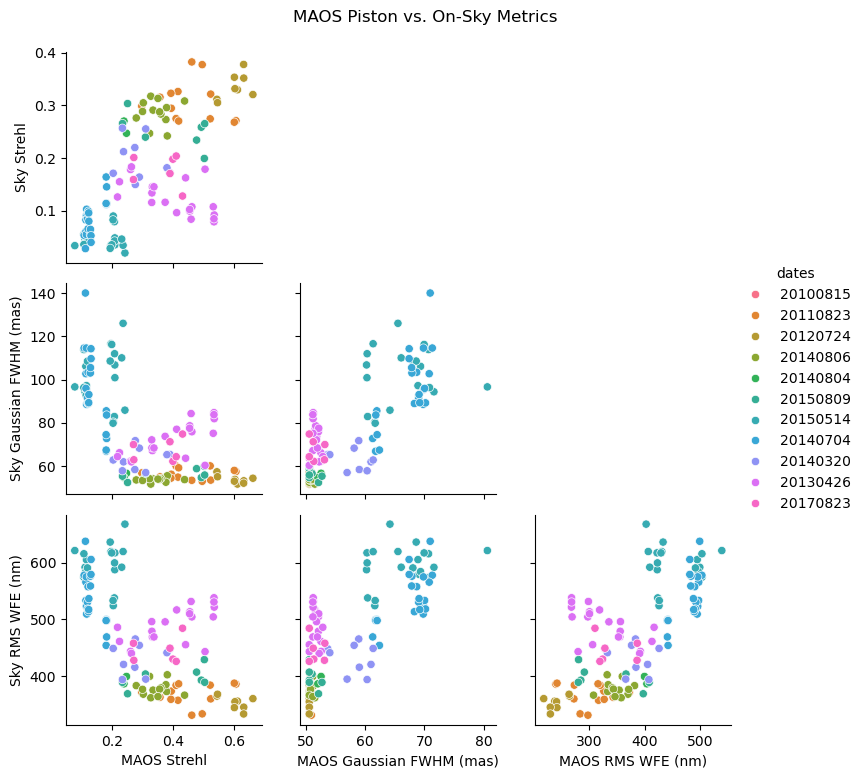

In [11]:
g = seaborn.PairGrid(piston_metrics, hue="dates", 
                     x_vars=['maosstrehls-piston', 'maosfwhms-piston', 'maosrmswfes-piston'], 
                     y_vars = ['skystrehls', 'skyfwhms', 'skyrmswfes'], corner=True)
g.map(seaborn.scatterplot)
g.add_legend()
g.x_vars = [r'MAOS Strehl', r'MAOS Gaussian FWHM (mas)', r'MAOS RMS WFE (nm)']
g.y_vars = [r'Sky Strehl', r'Sky Gaussian FWHM (mas)', r'Sky RMS WFE (nm)']
g._add_axis_labels()
g.fig.suptitle(r"MAOS Piston vs. On-Sky Metrics", y=1.03)

Text(0.5, 1.03, 'MAOS surfwfs1 vs. On-Sky Metrics')

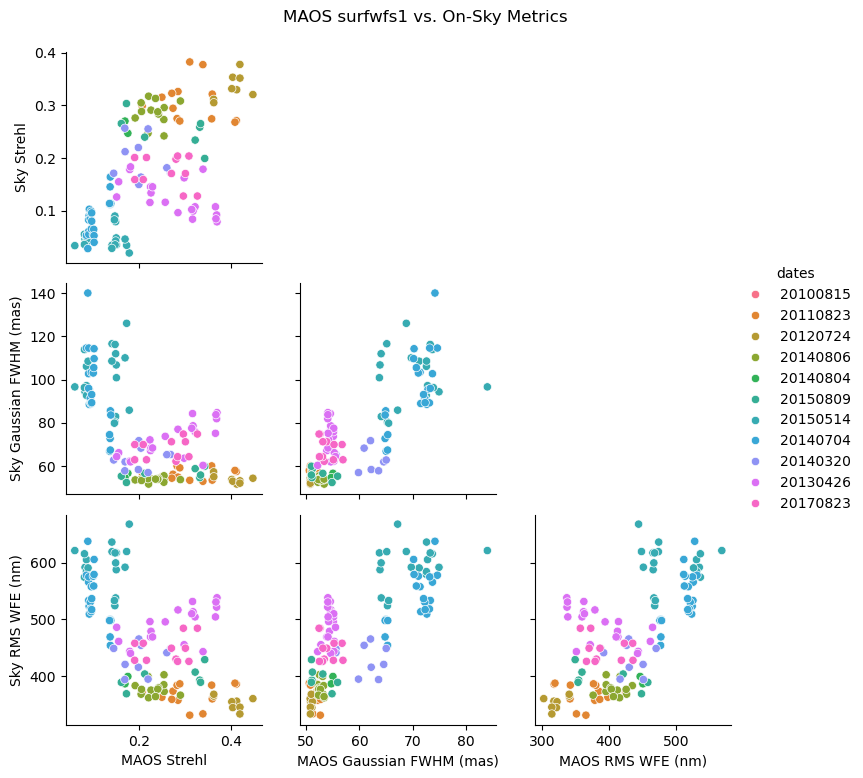

In [12]:
g = seaborn.PairGrid(surfwfs1_metrics, hue="dates", 
                     x_vars=['maosstrehls-psd+ncpa-seen', 'maosfwhms-psd+ncpa-seen', 'maosrmswfes-psd+ncpa-seen'], 
                     y_vars = ['skystrehls', 'skyfwhms', 'skyrmswfes'], corner=True)
g.map(seaborn.scatterplot)
g.add_legend()
g.x_vars = [r'MAOS Strehl', r'MAOS Gaussian FWHM (mas)', r'MAOS RMS WFE (nm)']
g.y_vars = [r'Sky Strehl', r'Sky Gaussian FWHM (mas)', r'Sky RMS WFE (nm)']
g._add_axis_labels()
g.fig.suptitle(r"MAOS surfwfs1 vs. On-Sky Metrics", y=1.03)

Text(0.5, 1.03, 'MAOS surfwfs0 vs. On-Sky Metrics')

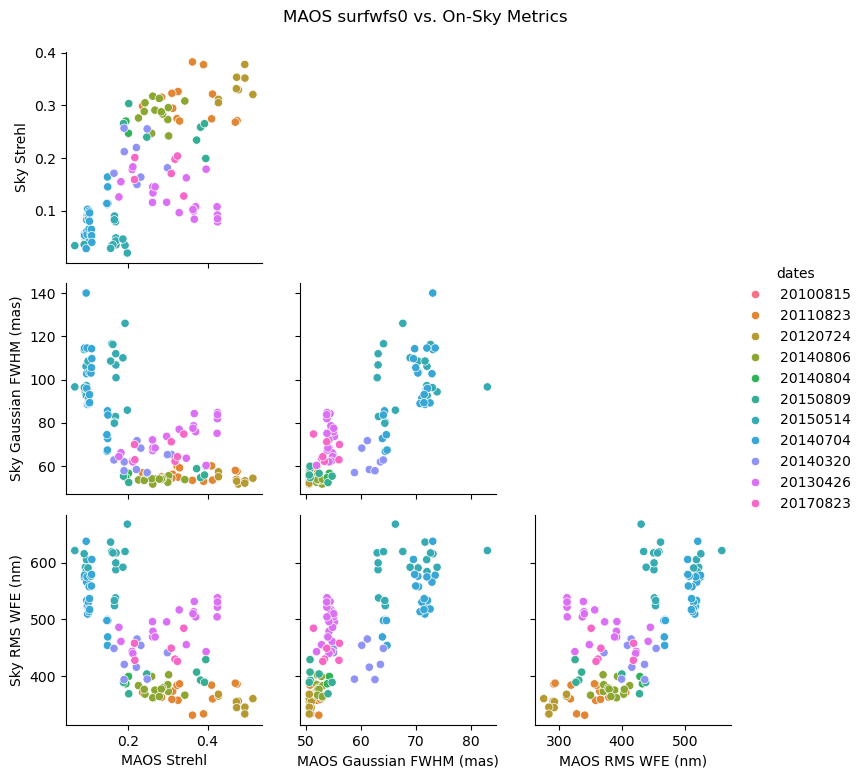

In [13]:
g = seaborn.PairGrid(surfwfs0_metrics, hue="dates", 
                     x_vars=['maosstrehls-psd+ncpa-unseen', 'maosfwhms-psd+ncpa-unseen', 'maosrmswfes-psd+ncpa-unseen'], 
                     y_vars = ['skystrehls', 'skyfwhms', 'skyrmswfes'], corner=True)
g.map(seaborn.scatterplot)
g.add_legend()
g.x_vars = [r'MAOS Strehl', r'MAOS Gaussian FWHM (mas)', r'MAOS RMS WFE (nm)']
g.y_vars = [r'Sky Strehl', r'Sky Gaussian FWHM (mas)', r'Sky RMS WFE (nm)']
g._add_axis_labels()
g.fig.suptitle(r"MAOS surfwfs0 vs. On-Sky Metrics", y=1.03)

In [5]:
plt.rcParams.update({
    "text.usetex": False, # turn off latex rendering,
    "font.sans-serif": "Helvetica",
})

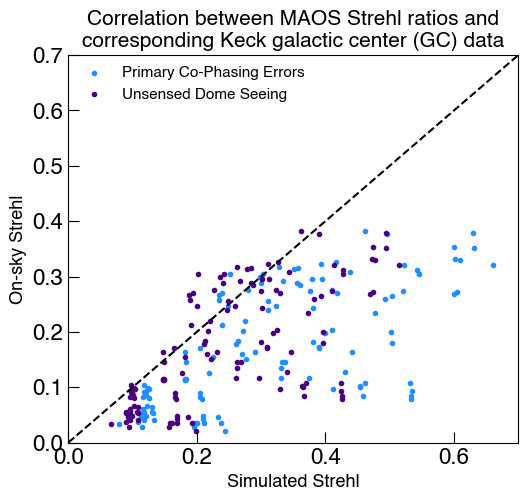

In [11]:
fig, axes = plt.subplots(figsize=(6.0, 5.0))
plt.scatter(all_modes['maosstrehls-piston'].astype(float), 
            all_modes['skystrehls'].astype(float), marker='.',
            label="Primary Co-Phasing Errors", color="dodgerblue")
# plt.scatter(all_modes['maosstrehls-psd+ncpa-seen'].astype(float), 
#             all_modes['skystrehls'].astype(float), marker='.',
#             label="psd+ncpa seen", color="green")
plt.scatter(all_modes['maosstrehls-psd+ncpa-unseen'].astype(float), 
            all_modes['skystrehls'].astype(float), marker='.',
            label="Unsensed Dome Seeing", color="indigo")
# plt.scatter(strehls, sky_sr, label="telemetry input (psd+ncpa-seen mode only)", marker="*", color="gold")
plt.title("Correlation between MAOS Strehl ratios and\ncorresponding Keck galactic center (GC) data", fontsize=15)

plt.ylim(0.0, 0.7)
plt.xlim(0.0, 0.7)
xlim = plt.gca().get_xlim()
plt.gca().tick_params(axis='both', direction='in')
plt.plot(xlim, xlim, 'k--')
plt.xlabel("Simulated Strehl", fontsize=13)
plt.ylabel("On-sky Strehl", fontsize=13)
# plt.tight_layout()
# plt.grid(linestyle='dotted')
plt.legend(ncol=1, frameon=False, fontsize="11")
plt.savefig('/Users/bdigia/work/ao/strehl_plot_20241113_final.png', dpi=fig.dpi)
plt.show()

``20100815`` epoch excluded from plot automatically because they are ``np.NaN``s in ``all_modes``

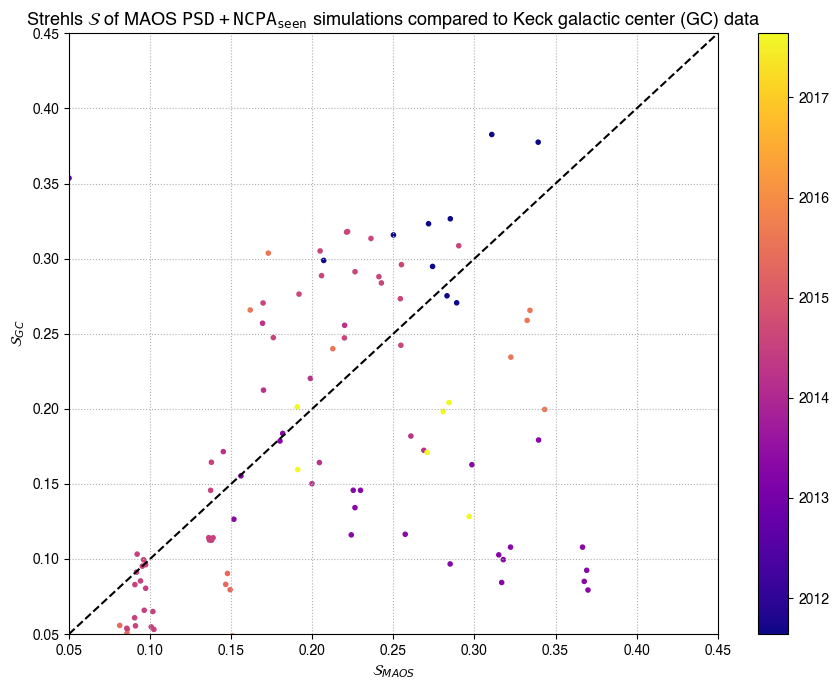

<Figure size 640x480 with 0 Axes>

In [15]:
import matplotlib.dates as mdates 
from datetime import datetime

fig, axes = plt.subplots(figsize=(9.0, 7.0))
customcolor = [mdates.date2num(datetime.strptime(i, "%Y%m%d")) for i in all_modes['dates'].values]
scatter = plt.scatter(all_modes['maosstrehls-psd+ncpa-seen'].astype(float), 
                      all_modes['skystrehls'].astype(float), marker='.',
                      label="psd+ncpa seen", c=customcolor, cmap=plt.cm.plasma)
# plt.scatter(strehls, sky_sr, label="telemetry input (psd+ncpa-seen mode only)", marker="*", color="gold")
plt.title(r"Strehls $\mathcal{S}$ of MAOS $\mathtt{PSD+NCPA_{seen}}$ simulations compared to Keck galactic center (GC) data", fontsize=13)

t = [mdates.date2num(datetime.strptime(i, "%Y%m%d")) for i in all_modes['dates'].values]
loc = mdates.AutoDateLocator()
fig.colorbar(scatter, ticks=loc, format=mdates.AutoDateFormatter(loc))

plt.ylim(0.05, 0.45)
plt.xlim(0.05, 0.45)
xlim = plt.gca().get_xlim()
plt.plot(xlim, xlim, 'k--')
plt.xlabel(r"$\mathcal{S}_{MAOS}$", fontsize=11)
plt.ylabel(r"$\mathcal{S}_{GC}$", fontsize=11)
plt.tight_layout()
plt.grid(linestyle='dotted')
# plt.legend(ncol=2)
plt.show()
plt.savefig('/Users/bdigia/work/ao/keck/maos/keck/my_base/strehl_plot_psd+ncpa_seen_08262024.eps', 
            format='eps', dpi=1000)

In [5]:
piston_diff = all_modes['maosstrehls-piston'].astype(float) - all_modes['skystrehls'].astype(float)
seen_diff = all_modes['maosstrehls-psd+ncpa-seen'].astype(float) - all_modes['skystrehls'].astype(float)
unseen_diff = all_modes['maosstrehls-psd+ncpa-unseen'].astype(float) - all_modes['skystrehls'].astype(float)

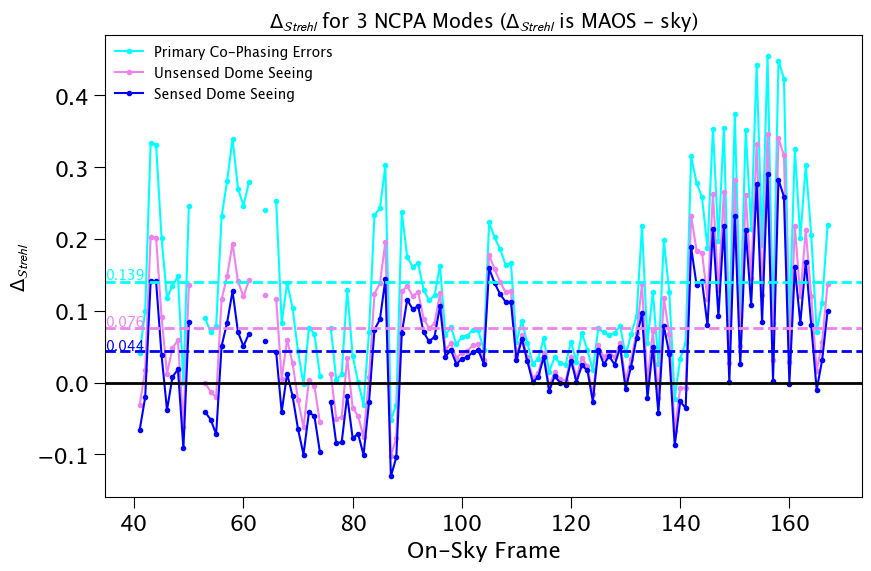

<Figure size 600x600 with 0 Axes>

In [21]:
fig, axes = plt.subplots(figsize=(9.0, 6.0))
plt.plot(piston_diff, '.-', label=r"Primary Co-Phasing Errors", color="cyan")
plt.plot(unseen_diff, '.-', label=r"Unsensed Dome Seeing", color="violet")
plt.plot(seen_diff, '.-', label=r"Sensed Dome Seeing", color="blue")
# Solid line on x-axis
plt.axhline(y=0.0, color='black', linewidth=2)
# Mean delta strehl, piston mode
plt.axhline(y=np.mean(piston_diff), color='cyan', linestyle='--', linewidth=2)
axes.text(axes.get_xlim()[0], np.mean(piston_diff)*1.03, s=f"{np.mean(piston_diff):.3f}", color='cyan', fontsize=10)
# Mean delta strehl, seen mode
plt.axhline(y=np.mean(seen_diff), color='blue', linestyle='--', linewidth=2)
axes.text(axes.get_xlim()[0], np.mean(seen_diff)*1.03, s=f"{np.mean(seen_diff):.3f}", color='blue', fontsize=10)
# Mean delta strehl, unseen mode
plt.axhline(y=np.mean(unseen_diff), color='violet', linestyle='--', linewidth=2)
axes.text(axes.get_xlim()[0], np.mean(unseen_diff)*1.03, s=f"{np.mean(unseen_diff):.3f}", color='violet', fontsize=10)
plt.title(r"$\Delta_{\mathcal{Strehl}}$ for 3 NCPA Modes ($\Delta_{\mathcal{Strehl}}$ is MAOS - sky)", 
          fontsize=14)
plt.xlabel("On-Sky Frame", fontsize=16)
plt.ylabel(r"$\Delta_{\mathcal{Strehl}}$", fontsize=14)
plt.tight_layout()
# plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend(fontsize=10, frameon=False, ncol=1)
plt.show()
plt.savefig('/Users/bdigia/work/ao/keck/maos/keck/my_base/delta_strehl_plot_08262024.eps', 
            format='eps', dpi=1000)

In [18]:
gaussian_fwhm_piston_diff = all_modes['maosfwhms-piston'].astype(float) - all_modes['skyfwhms'].astype(float)
gaussian_fwhm_seen_diff = all_modes['maosfwhms-psd+ncpa-seen'].astype(float) - all_modes['skyfwhms'].astype(float)
gaussian_fwhm_unseen_diff = all_modes['maosfwhms-psd+ncpa-unseen'].astype(float) - all_modes['skyfwhms'].astype(float)

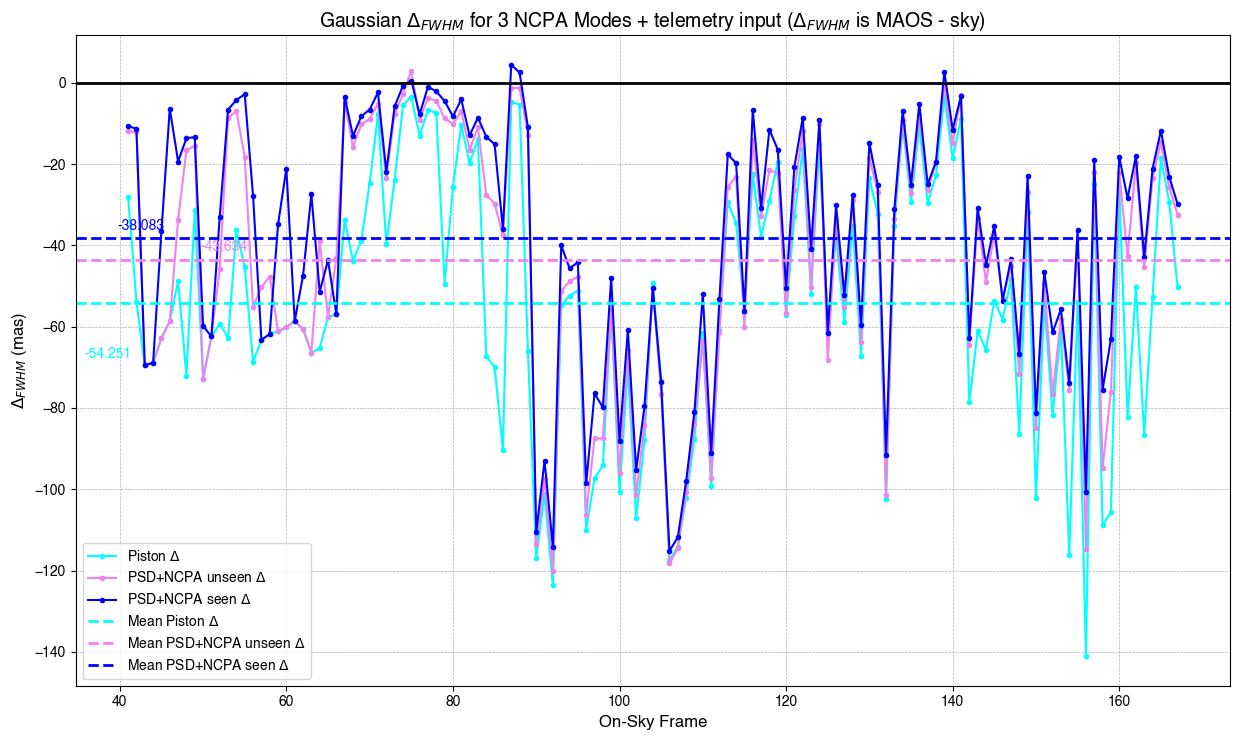

<Figure size 640x480 with 0 Axes>

In [19]:
fig, axes = plt.subplots(figsize=(12.5, 7.5))
plt.plot(gaussian_fwhm_piston_diff, '.-', label=r"Piston $\Delta$", color="cyan")
plt.plot(gaussian_fwhm_unseen_diff, '.-', label=r"PSD+NCPA unseen $\Delta$", color="violet")
plt.plot(gaussian_fwhm_seen_diff, '.-', label=r"PSD+NCPA seen $\Delta$", color="blue")
# Solid line on x-axis
plt.axhline(y=0.0, color='black', linewidth=2)
# Mean delta fwhm, piston mode
plt.axhline(y=np.mean(gaussian_fwhm_piston_diff), color='cyan', linestyle='--', linewidth=2, label=r"Mean Piston $\Delta$")
axes.text(axes.get_xlim()[0]+1, np.mean(gaussian_fwhm_piston_diff)*1.25, s=f"{np.mean(gaussian_fwhm_piston_diff):.3f}", color='cyan')
# Mean delta fwhm, unseen mode
plt.axhline(y=np.mean(gaussian_fwhm_unseen_diff), color='violet', linestyle='--', linewidth=2, label=r"Mean PSD+NCPA unseen $\Delta$")
axes.text(axes.get_xlim()[0]+15, np.mean(gaussian_fwhm_unseen_diff)*0.95, s=f"{np.mean(gaussian_fwhm_unseen_diff):.3f}", color='violet')
# Mean delta fwhm, seen mode
plt.axhline(y=np.mean(gaussian_fwhm_seen_diff), color='blue', linestyle='--', linewidth=2, label=r"Mean PSD+NCPA seen $\Delta$")
axes.text(axes.get_xlim()[0]+5, np.mean(gaussian_fwhm_seen_diff)*0.95, s=f"{np.mean(gaussian_fwhm_seen_diff):.3f}", color='blue')
plt.title(r"Gaussian $\Delta_{FWHM}$ for 3 NCPA Modes + telemetry input ($\Delta_{FWHM}$ is MAOS - sky)", 
          fontsize=14)
plt.xlabel("On-Sky Frame", fontsize=12)
plt.ylabel(r"$\Delta_{FWHM}$ (mas)", fontsize=12)
plt.tight_layout()
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.show()
plt.savefig('/Users/bdigia/work/ao/keck/maos/keck/my_base/delta_gaussian_fwhm_plot_08262024.eps', 
            format='eps', dpi=1000)

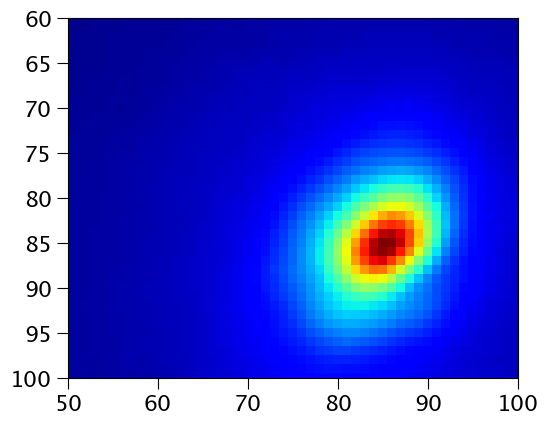

In [22]:
from astropy.io import fits
with fits.open('/Users/bdigia/work/ao/airopa_input/20150514nirc2_kp/c1090_psf.fits') as file:
    hdr = file[0].header
    img = file[0].data
    plt.imshow(img)
    plt.xlim(50.0,100.0)
    plt.ylim(100.0, 60.0)

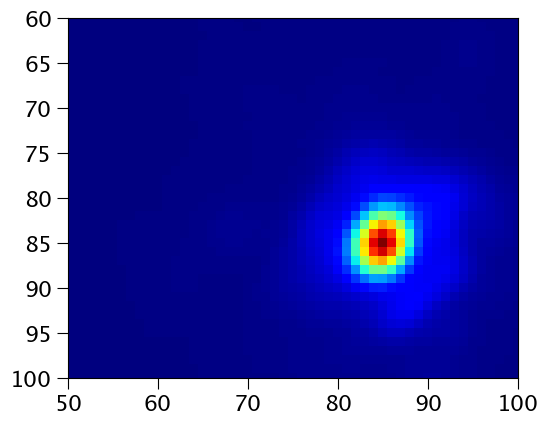

In [23]:
from astropy.io import fits
with fits.open('/Users/bdigia/work/ao/airopa_input/20150809nirc2_kp/c0207_psf.fits') as file:
    hdr = file[0].header
    img = file[0].data
    plt.imshow(img)
    plt.xlim(50.0,100.0)
    plt.ylim(100.0, 60.0)

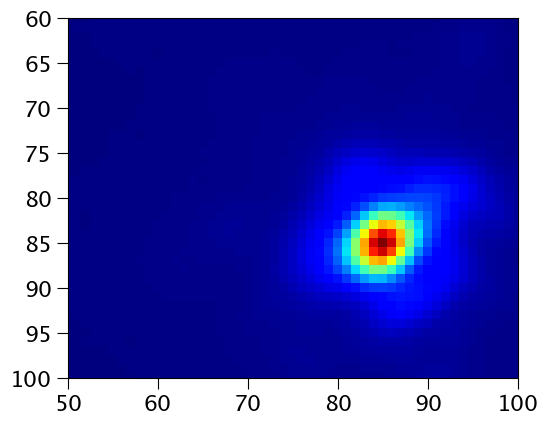

In [24]:
from astropy.io import fits
with fits.open('/Users/bdigia/work/ao/airopa_input/20150809nirc2_kp/c0210_psf.fits') as file:
    hdr = file[0].header
    img = file[0].data
    plt.imshow(img)
    plt.xlim(50.0,100.0)
    plt.ylim(100.0, 60.0)

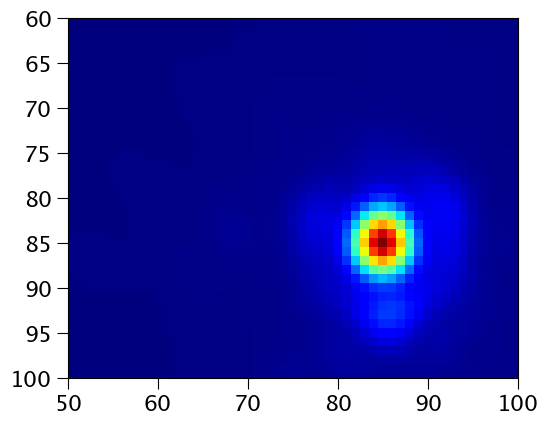

In [25]:
from astropy.io import fits
with fits.open('/Users/bdigia/work/ao/airopa_input/20140804nirc2_kp/c0121_psf.fits') as file:
    hdr = file[0].header
    img = file[0].data
    plt.imshow(img)
    plt.xlim(50.0,100.0)
    plt.ylim(100.0, 60.0)

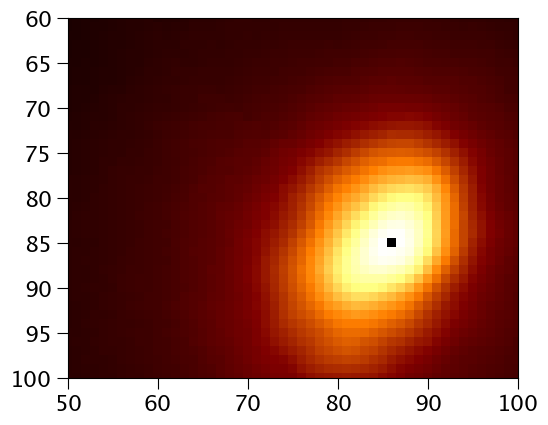

In [27]:
from astropy.io import fits
with fits.open('/Users/bdigia/work/ao/airopa_input/20150514nirc2_kp/c1095_psf.fits') as file:
    hdr = file[0].header
    img = file[0].data
    plt.imshow(img, cmap=plt.cm.afmhot)
    plt.xlim(50.0,100.0)
    plt.ylim(100.0, 60.0)

In [20]:
emp_fwhm_piston_diff = all_modes['maosempfwhms-piston'].astype(float) - all_modes['skyempfwhms'].astype(float)
emp_fwhm_seen_diff = all_modes['maosempfwhms-psd+ncpa-seen'].astype(float) - all_modes['skyempfwhms'].astype(float)
emp_fwhm_unseen_diff = all_modes['maosempfwhms-psd+ncpa-unseen'].astype(float) - all_modes['skyempfwhms'].astype(float)

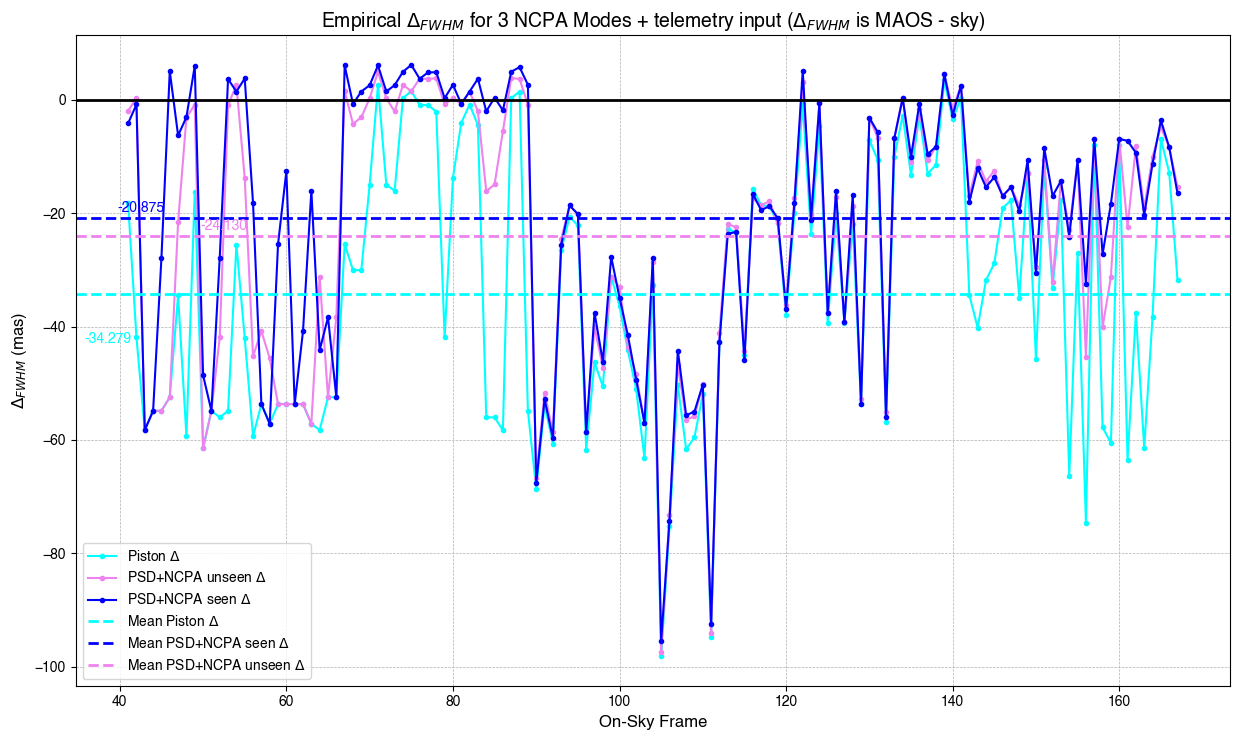

<Figure size 640x480 with 0 Axes>

In [21]:
fig, axes = plt.subplots(figsize=(12.5, 7.5))
plt.plot(emp_fwhm_piston_diff, '.-', label=r"Piston $\Delta$", color="cyan")
plt.plot(emp_fwhm_unseen_diff, '.-', label=r"PSD+NCPA unseen $\Delta$", color="violet")
plt.plot(emp_fwhm_seen_diff, '.-', label=r"PSD+NCPA seen $\Delta$", color="blue")
# Solid line on x-axis
plt.axhline(y=0.0, color='black', linewidth=2)
# Mean delta fwhm, piston mode
plt.axhline(y=np.mean(emp_fwhm_piston_diff), color='cyan', linestyle='--', linewidth=2, label=r"Mean Piston $\Delta$")
axes.text(axes.get_xlim()[0]+1, np.mean(emp_fwhm_piston_diff)*1.25, s=f"{np.mean(emp_fwhm_piston_diff):.3f}", color='cyan')
# Mean delta fwhm, seen mode
plt.axhline(y=np.mean(emp_fwhm_seen_diff), color='blue', linestyle='--', linewidth=2, label=r"Mean PSD+NCPA seen $\Delta$")
axes.text(axes.get_xlim()[0]+5, np.mean(emp_fwhm_seen_diff)*0.95, s=f"{np.mean(emp_fwhm_seen_diff):.3f}", color='blue')
# Mean delta fwhm, unseen mode
plt.axhline(y=np.mean(emp_fwhm_unseen_diff), color='violet', linestyle='--', linewidth=2, label=r"Mean PSD+NCPA unseen $\Delta$")
axes.text(axes.get_xlim()[0]+15, np.mean(emp_fwhm_unseen_diff)*0.95, s=f"{np.mean(emp_fwhm_unseen_diff):.3f}", color='violet')
plt.title(r"Empirical $\Delta_{FWHM}$ for 3 NCPA Modes + telemetry input ($\Delta_{FWHM}$ is MAOS - sky)", 
          fontsize=14)
plt.xlabel("On-Sky Frame", fontsize=12)
plt.ylabel(r"$\Delta_{FWHM}$ (mas)", fontsize=12)
plt.tight_layout()
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.show()
plt.savefig('/Users/bdigia/work/ao/keck/maos/keck/my_base/delta_emp_fwhm_plot_08262024.eps', 
            format='eps', dpi=1000)

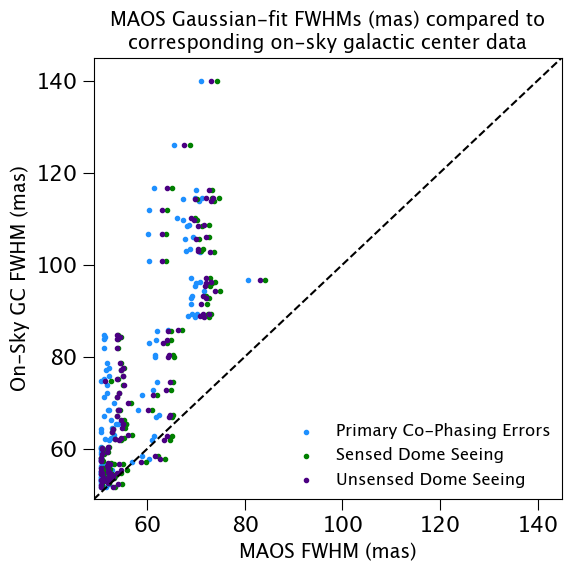

<Figure size 600x600 with 0 Axes>

In [35]:
fig, axes = plt.subplots(figsize=(6.0, 6.0))
plt.scatter(all_modes['maosfwhms-piston'].astype(float), 
            all_modes['skyfwhms'].astype(float), marker='.',
            label="Primary Co-Phasing Errors", color="dodgerblue")
plt.scatter(all_modes['maosfwhms-psd+ncpa-seen'].astype(float), 
            all_modes['skyfwhms'].astype(float), marker='.',
            label="Sensed Dome Seeing", color="green")
plt.scatter(all_modes['maosfwhms-psd+ncpa-unseen'].astype(float), 
            all_modes['skyfwhms'].astype(float), marker='.',
            label="Unsensed Dome Seeing", color="indigo")
# plt.scatter(fwhms, sky_fwhm, label="telemetry input (psd+ncpa-seen)", marker="*", color="gold")
plt.title("MAOS Gaussian-fit FWHMs (mas) compared to\ncorresponding on-sky galactic center data", fontsize=14)

plt.ylim(49.0, 145.0)
plt.xlim(49.0, 145.0)
xlim = plt.gca().get_xlim()
plt.plot(xlim, xlim, 'k--')
plt.xlabel(r"MAOS FWHM (mas)", fontsize=14)
plt.ylabel(r"On-Sky GC FWHM (mas)", fontsize=14)
plt.tight_layout()
# plt.grid(linestyle='dotted')
plt.legend(ncol=1, frameon=False, fontsize=12)
plt.show()
plt.savefig('/Users/bdigia/work/ao/keck/maos/keck/my_base/gaussian_fwhm_plot_08262024.eps', 
            format='eps', dpi=1000)

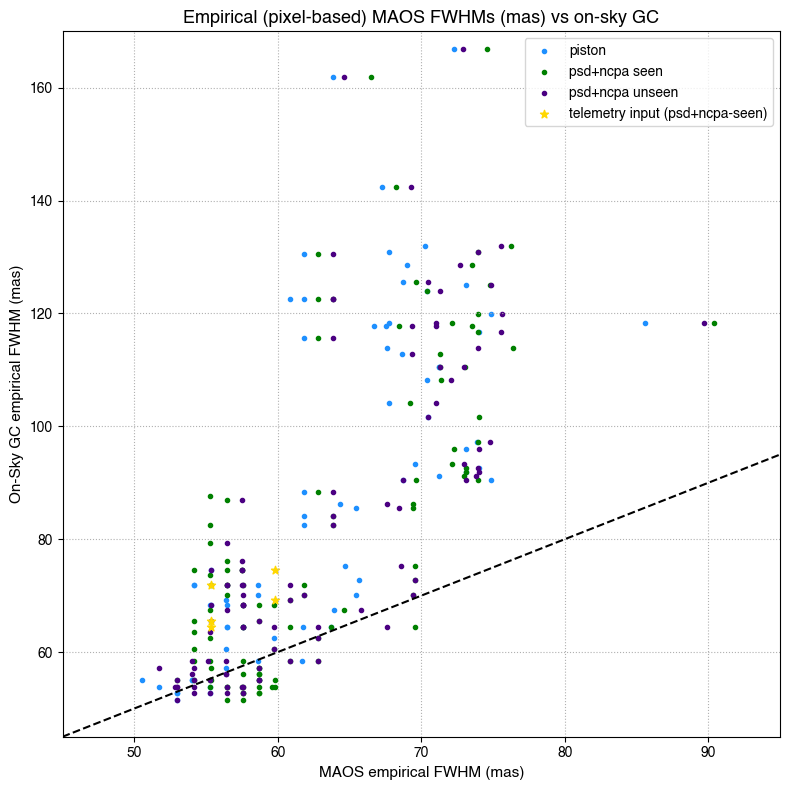

<Figure size 640x480 with 0 Axes>

In [23]:
fig, axes = plt.subplots(figsize=(8.0, 8.0))
plt.scatter(all_modes['maosempfwhms-piston'].astype(float), 
            all_modes['skyempfwhms'].astype(float), marker='.',
            label="piston", color="dodgerblue")
plt.scatter(all_modes['maosempfwhms-psd+ncpa-seen'].astype(float), 
            all_modes['skyempfwhms'].astype(float), marker='.',
            label="psd+ncpa seen", color="green")
plt.scatter(all_modes['maosempfwhms-psd+ncpa-unseen'].astype(float), 
            all_modes['skyempfwhms'].astype(float), marker='.',
            label="psd+ncpa unseen", color="indigo")
plt.scatter(emp_fwhms, sky_empfwhm, label="telemetry input (psd+ncpa-seen)", marker="*", color="gold")
plt.title(r"Empirical (pixel-based) MAOS FWHMs (mas) vs on-sky GC", fontsize=13)

plt.ylim(45.0, 170.0)
plt.xlim(45.0, 95.0)
xlim = plt.gca().get_xlim()
plt.plot(xlim, xlim, 'k--')
plt.xlabel(r"MAOS empirical FWHM (mas)", fontsize=11)
plt.ylabel(r"On-Sky GC empirical FWHM (mas)", fontsize=11)
plt.tight_layout()
plt.grid(linestyle='dotted')
plt.legend(ncol=1)
plt.show()
plt.savefig('/Users/bdigia/work/ao/keck/maos/keck/my_base/empirical_fwhm_plot_08262024.eps', 
            format='eps', dpi=1000)

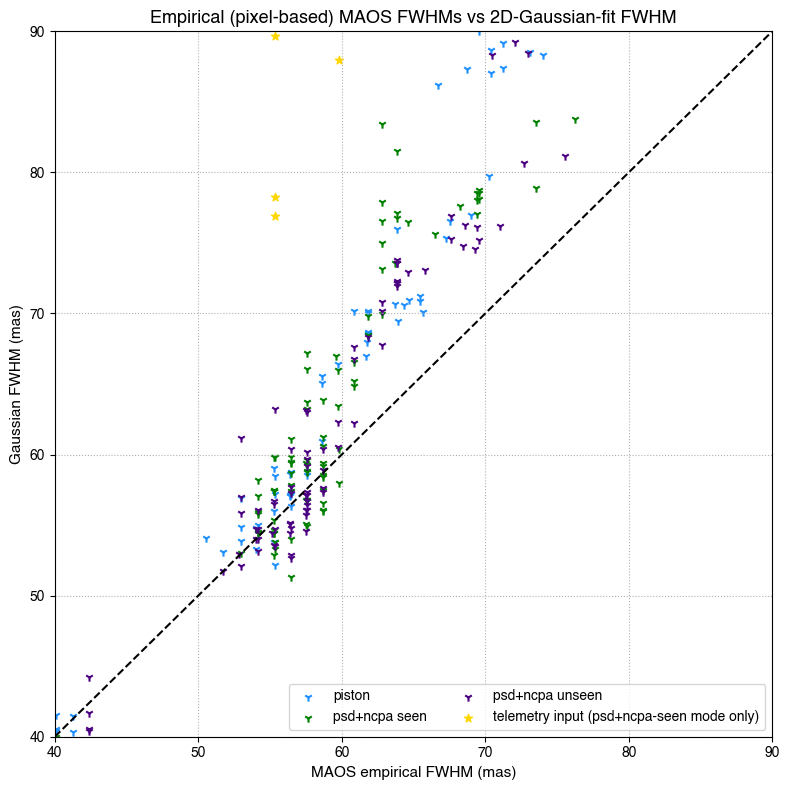

In [24]:
fig, axes = plt.subplots(figsize=(8.0, 8.0))
plt.scatter(all_modes[40:]['maosempfwhms-piston'].astype(float), 
            all_modes[40:]['maosfwhms-piston'].astype(float), marker='1',
            label="piston", color="dodgerblue")
plt.scatter(all_modes[40:]['maosempfwhms-psd+ncpa-seen'].astype(float), 
            all_modes[40:]['maosfwhms-psd+ncpa-seen'].astype(float), marker='1',
            label="psd+ncpa seen", color="green")
plt.scatter(all_modes[40:]['maosempfwhms-psd+ncpa-unseen'].astype(float), 
            all_modes[40:]['maosfwhms-psd+ncpa-unseen'].astype(float), marker='1',
            label="psd+ncpa unseen", color="indigo")
plt.scatter(emp_fwhms, sky_fwhm, label="telemetry input (psd+ncpa-seen mode only)", marker="*", color="gold")
plt.title("Empirical (pixel-based) MAOS FWHMs vs 2D-Gaussian-fit FWHM", fontsize=13)

plt.ylim(40.0, 90.0)
plt.xlim(40.0, 90.0)
xlim = plt.gca().get_xlim()
plt.plot(xlim, xlim, 'k--')
plt.xlabel(r"MAOS empirical FWHM (mas)", fontsize=11)
plt.ylabel(r"Gaussian FWHM (mas)", fontsize=11)
plt.tight_layout()
plt.grid(linestyle='dotted')
plt.legend(ncol=2)
plt.show()

### **Correlations with $\tau_{0}$, $\theta_{0}$, $r_{0}$**

In [41]:
strehl_piston_diff = all_modes['maosstrehls-piston'].astype(float) - all_modes['skystrehls'].astype(float)
fwhm_piston_diff = all_modes['maosfwhms-piston'].astype(float) - all_modes['skyfwhms'].astype(float)
rmswfe_piston_diff = all_modes['maosrmswfes-piston'].astype(float) - all_modes['skyrmswfes'].astype(float)

strehl_seen_diff = all_modes['maosstrehls-psd+ncpa-seen'].astype(float) - all_modes['skystrehls'].astype(float)
fwhm_seen_diff = all_modes['maosfwhms-psd+ncpa-seen'].astype(float) - all_modes['skyfwhms'].astype(float)
rmswfe_seen_diff = all_modes['maosrmswfes-psd+ncpa-seen'].astype(float) - all_modes['skyrmswfes'].astype(float)

strehl_unseen_diff = all_modes['maosstrehls-psd+ncpa-unseen'].astype(float) - all_modes['skystrehls'].astype(float)
fwhm_unseen_diff = all_modes['maosfwhms-psd+ncpa-unseen'].astype(float) - all_modes['skyfwhms'].astype(float)
rmswfe_unseen_diff = all_modes['maosrmswfes-psd+ncpa-unseen'].astype(float) - all_modes['skyrmswfes'].astype(float)

out = np.column_stack((all_modes['tau0'].astype(float), all_modes['theta0'].astype(float), 
                       all_modes['frieds'].astype(float), strehl_piston_diff, 
                       fwhm_piston_diff, rmswfe_piston_diff, all_modes['dates']))
col_list = ['tau0', 'theta0', 'r0', 'delta_strehl_piston', 'delta_fwhm_piston', 'delta_rmswfe_piston', 'dates']
piston_for_plotting = pd.DataFrame(np.array(out), columns=col_list)

out = np.column_stack((all_modes['tau0'].astype(float), all_modes['theta0'].astype(float), 
                       all_modes['frieds'].astype(float), strehl_seen_diff, 
                       fwhm_seen_diff, rmswfe_seen_diff, all_modes['dates']))
col_list = ['tau0', 'theta0', 'r0', 'delta_strehl_surfwfs1', 'delta_fwhm_surfwfs1', 'delta_rmswfe_surfwfs1', 'dates']
surfwfs1_for_plotting = pd.DataFrame(np.array(out), columns=col_list)

out = np.column_stack((all_modes['tau0'].astype(float), all_modes['theta0'].astype(float), 
                       all_modes['frieds'].astype(float), strehl_unseen_diff, 
                       fwhm_unseen_diff, rmswfe_unseen_diff, all_modes['dates']))
col_list = ['tau0', 'theta0', 'r0', 'delta_strehl_surfwfs0', 'delta_fwhm_surfwfs0', 'delta_rmswfe_surfwfs0', 'dates']
surfwfs0_for_plotting = pd.DataFrame(np.array(out), columns=col_list)

Text(0.5, 1.03, 'Metric $\\Delta$s for MAOS Piston Simulations')

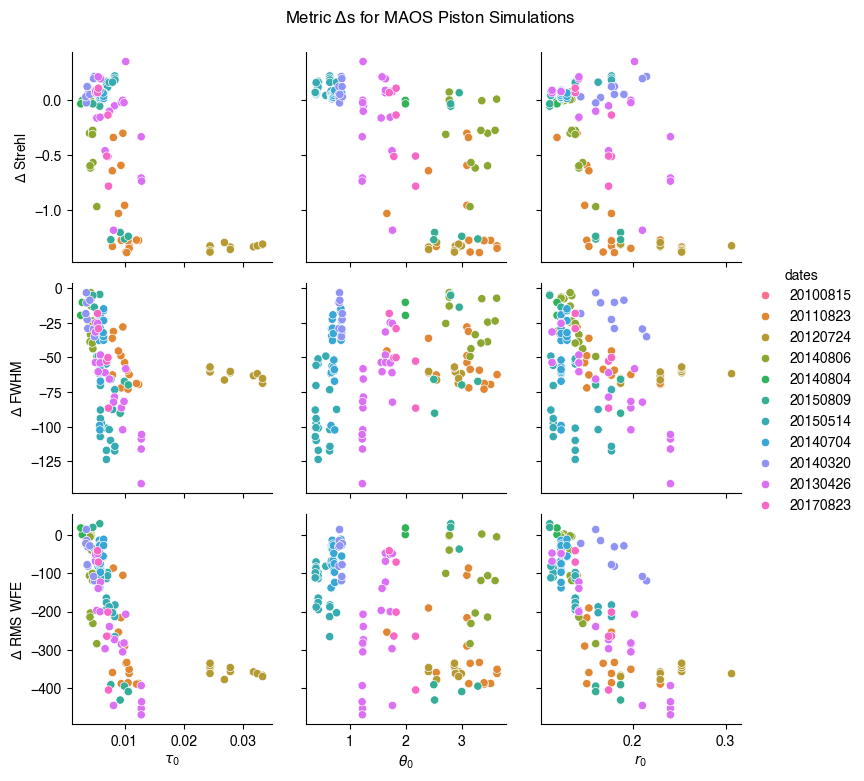

In [26]:
g = seaborn.PairGrid(piston_for_plotting, hue="dates", x_vars=['tau0', 'theta0', 'r0'], y_vars = ['delta_strehl_piston', 'delta_fwhm_piston', 'delta_rmswfe_piston'])
g.map(seaborn.scatterplot)
g.add_legend()
g.x_vars = [r'$\tau_{0}$', r'$\theta_{0}$', r'$r_{0}$']
g.y_vars = [r'$\Delta$ Strehl', r'$\Delta$ FWHM', r'$\Delta$ RMS WFE']
g._add_axis_labels()
g.fig.suptitle(r"Metric $\Delta$s for MAOS Piston Simulations", y=1.03)

Text(0.5, 1.03, 'Metric $\\Delta$s for MAOS Unseen PSD$+$NCPA Simulations')

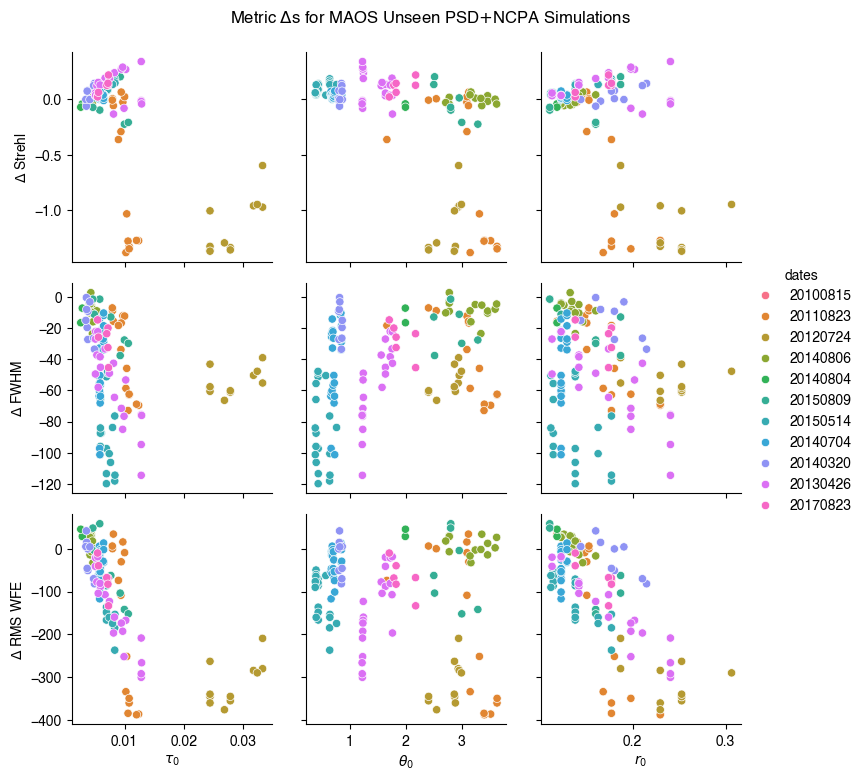

In [27]:
g = seaborn.PairGrid(surfwfs0_for_plotting, hue="dates", x_vars=['tau0', 'theta0', 'r0'], y_vars = ['delta_strehl_surfwfs0', 'delta_fwhm_surfwfs0', 'delta_rmswfe_surfwfs0'])
g.map(seaborn.scatterplot)
g.add_legend()
g.x_vars = [r'$\tau_{0}$', r'$\theta_{0}$', r'$r_{0}$']
g.y_vars = [r'$\Delta$ Strehl', r'$\Delta$ FWHM', r'$\Delta$ RMS WFE']
g._add_axis_labels()
g.fig.suptitle(r"Metric $\Delta$s for MAOS Unseen PSD$+$NCPA Simulations", y=1.03)

Text(0.5, 1.03, 'Metric $\\Delta$s for MAOS Seen PSD$+$NCPA Simulations')

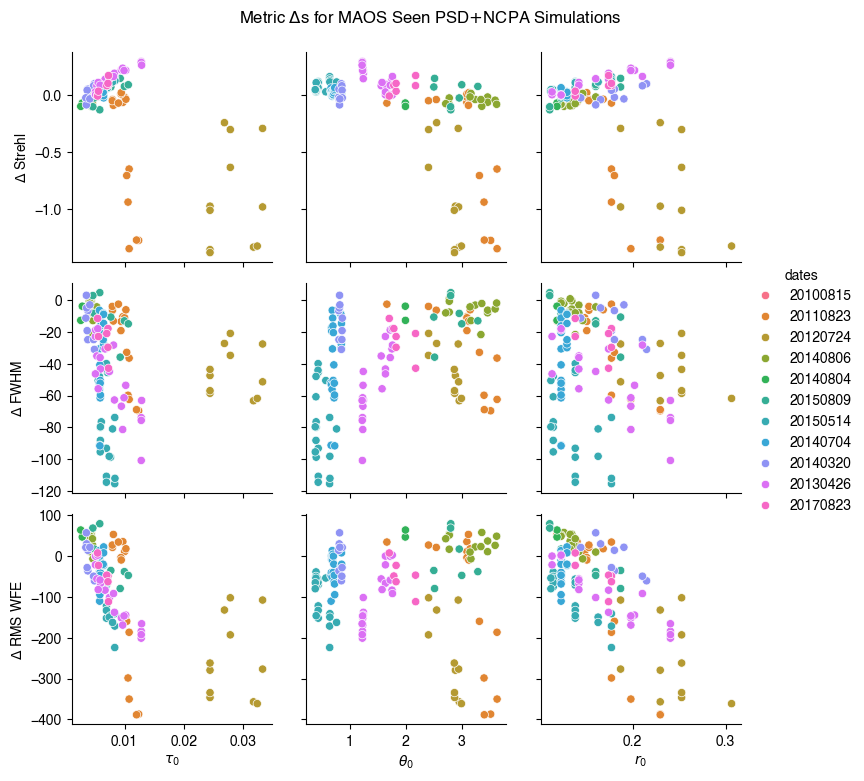

In [28]:
g = seaborn.PairGrid(surfwfs1_for_plotting, hue="dates", x_vars=['tau0', 'theta0', 'r0'], y_vars = ['delta_strehl_surfwfs1', 'delta_fwhm_surfwfs1', 'delta_rmswfe_surfwfs1'])
g.map(seaborn.scatterplot)
g.add_legend()
g.x_vars = [r'$\tau_{0}$', r'$\theta_{0}$', r'$r_{0}$']
g.y_vars = [r'$\Delta$ Strehl', r'$\Delta$ FWHM', r'$\Delta$ RMS WFE']
g._add_axis_labels()
g.fig.suptitle(r"Metric $\Delta$s for MAOS Seen PSD$+$NCPA Simulations", y=1.03)

#### **Correlations *between* $\tau_{0}$, $\theta_{0}$, $r_{0}$**

In [140]:
out = np.column_stack((all_modes['tau0'].astype(float), all_modes['theta0'].astype(float), 
                       all_modes['frieds'].astype(float), all_modes['dates']))
col_list = ['tau0', 'theta0', 'r0', 'dates']
atm = pd.DataFrame(np.array(out), columns=col_list)

Text(0.5, 1.03, 'Correlations between atmospheric parameters $\\tau_{0}$, $\\theta_{0}$, $r_{0}$')

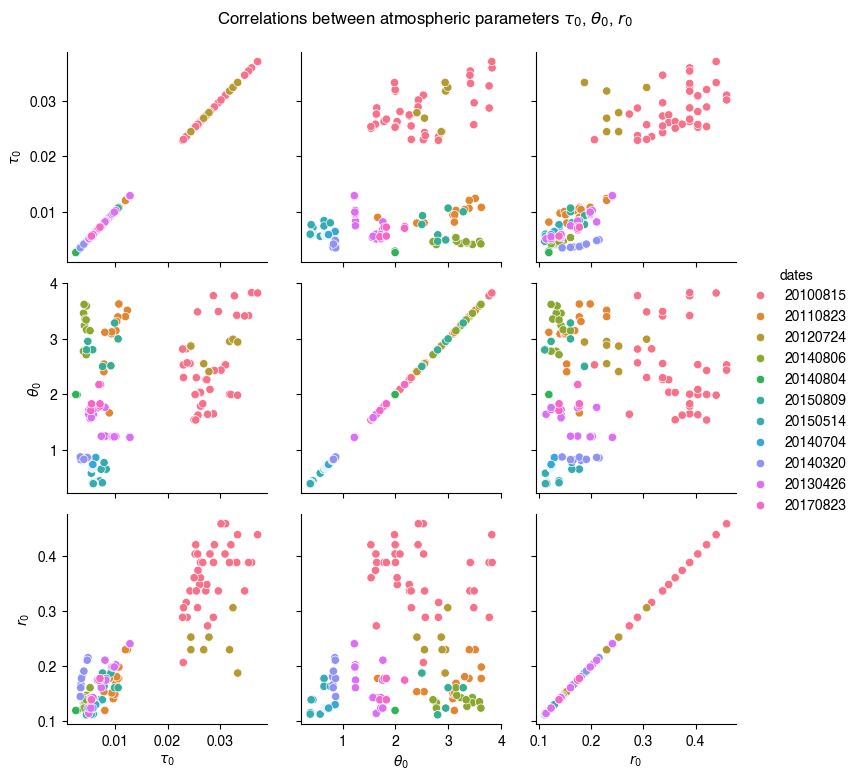

In [141]:
g = seaborn.PairGrid(atm, hue="dates")
g.map(seaborn.scatterplot)
g.add_legend()
g.x_vars = [r'$\tau_{0}$', r'$\theta_{0}$', r'$r_{0}$']
g.y_vars = [r'$\tau_{0}$', r'$\theta_{0}$', r'$r_{0}$']
g._add_axis_labels()
g.fig.suptitle(r"Correlations between atmospheric parameters $\tau_{0}$, $\theta_{0}$, $r_{0}$", y=1.03)

#### **$r_{0}$ vs $\tau_{0}$, colored by $\Delta_{\text{Strehl}}$ and $\Delta_{\text{FWHM}}$**

In [142]:
piston_for_plotting.keys()

Index(['tau0', 'theta0', 'r0', 'delta_strehl_piston', 'delta_fwhm_piston',
       'delta_rmswfe_piston', 'dates'],
      dtype='object')

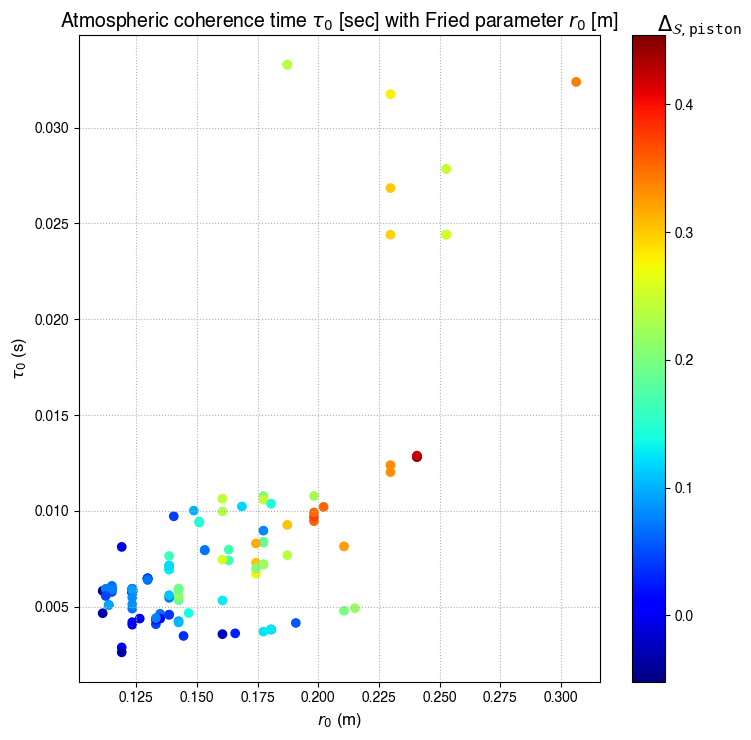

In [168]:
fig, axes = plt.subplots(figsize=(7.5, 7.5))
plt.scatter(piston_for_plotting['r0'], piston_for_plotting['tau0'], c=piston_for_plotting['delta_strehl_piston'], cmap=plt.cm.jet)
plt.title(r"Atmospheric coherence time $\tau_{0}$ [sec] with Fried parameter $r_{0}$ [m]", fontsize=14)
plt.xlabel("$r_{0}$ (m)", fontsize=12)
plt.ylabel(r"$\tau_{0}$ (s)", fontsize=12)
plt.tight_layout()
plt.grid(True, linestyle='dotted')
cbar = plt.colorbar()
cbar.set_label(r'$\Delta_{\mathcal{S}, \mathtt{piston}}$', rotation=0, y=1.035, fontsize=15)
plt.show()

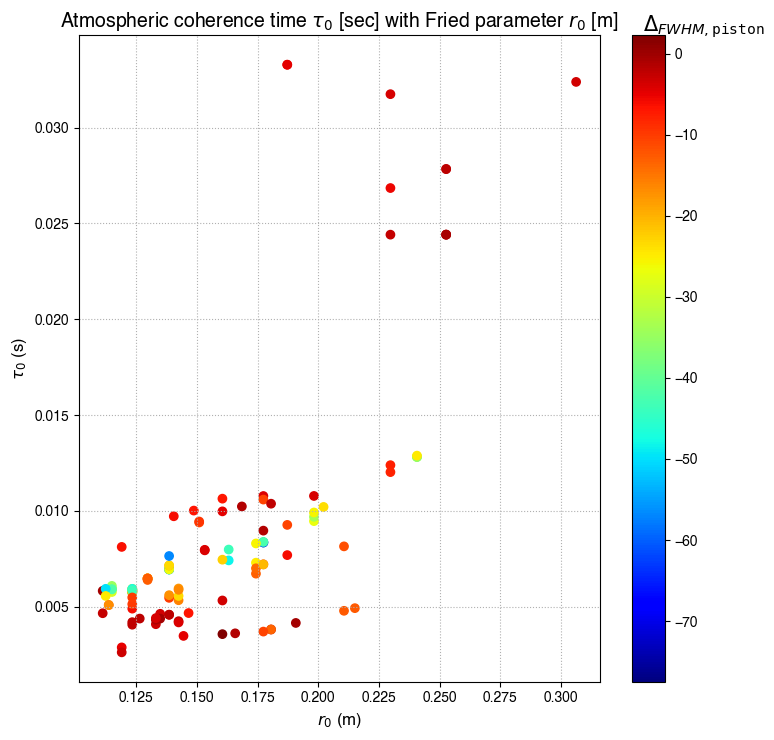

In [169]:
fig, axes = plt.subplots(figsize=(7.5, 7.5))
plt.scatter(piston_for_plotting['r0'], piston_for_plotting['tau0'], c=piston_for_plotting['delta_fwhm_piston'], cmap=plt.cm.jet)
plt.title(r"Atmospheric coherence time $\tau_{0}$ [sec] with Fried parameter $r_{0}$ [m]", fontsize=14)
plt.xlabel("$r_{0}$ (m)", fontsize=12)
plt.ylabel(r"$\tau_{0}$ (s)", fontsize=12)
plt.tight_layout()
plt.grid(True, linestyle='dotted')
cbar = plt.colorbar()
cbar.set_label(r'$\Delta_{FWHM, \mathtt{piston}}$', rotation=0, y=1.035, fontsize=15)
plt.show()

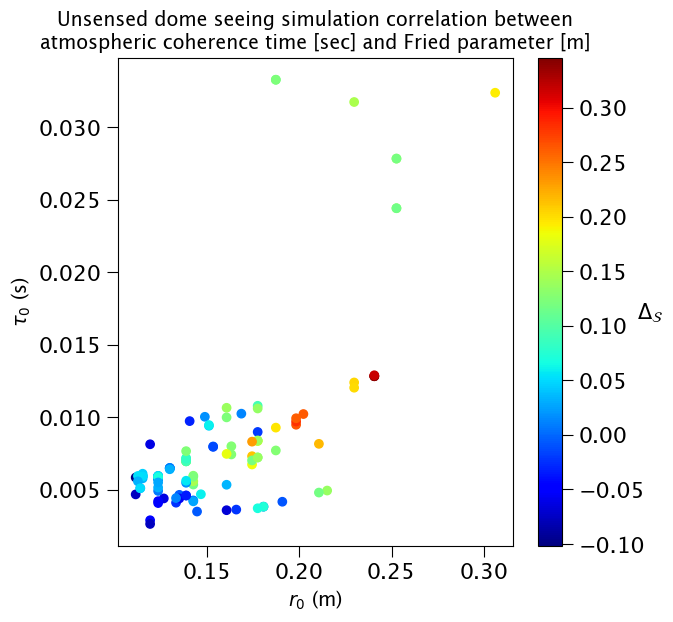

In [58]:
fig, axes = plt.subplots(figsize=(6.5, 6.5))
plt.scatter(surfwfs0_for_plotting['r0'], surfwfs0_for_plotting['tau0'], c=surfwfs0_for_plotting['delta_strehl_surfwfs0'], cmap=plt.cm.jet)
plt.title("Unsensed dome seeing simulation correlation between\natmospheric coherence time [sec] and Fried parameter [m]", fontsize=14)
# plt.axline((0, 0), (1, 1), linewidth=1, color='black', linestyle="--")
plt.xlabel("$r_{0}$ (m)", fontsize=14)
plt.ylabel(r"$\tau_{0}$ (s)", fontsize=14)
plt.tight_layout()
# plt.grid(True, linestyle='dotted')
cbar = plt.colorbar()
cbar.set_label(r'$\Delta_{\mathcal{S}}$', rotation=0, y=0.5, fontsize=15)
plt.show()

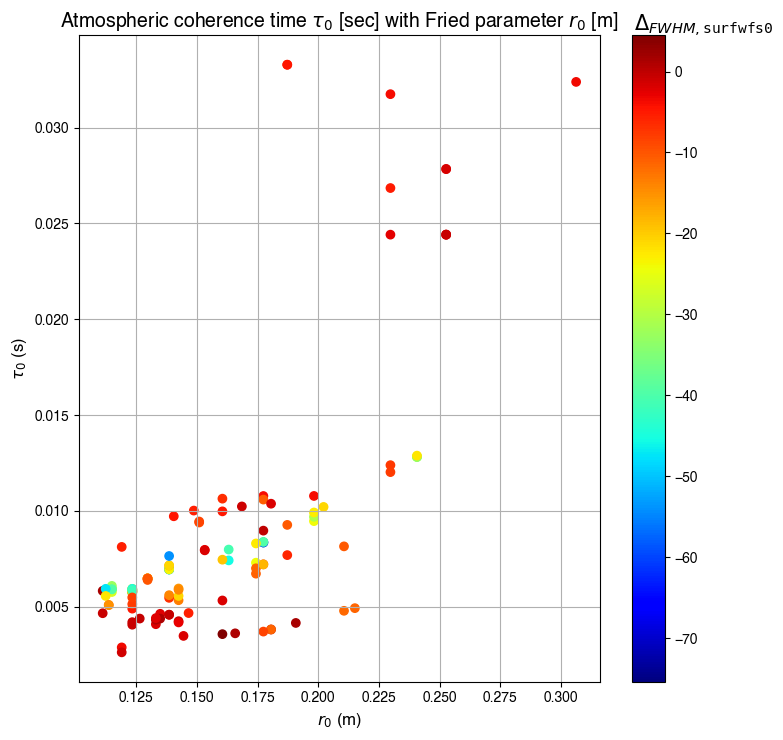

In [171]:
fig, axes = plt.subplots(figsize=(7.5, 7.5))
plt.scatter(surfwfs0_for_plotting['r0'], surfwfs0_for_plotting['tau0'], c=surfwfs0_for_plotting['delta_fwhm_surfwfs0'], cmap=plt.cm.jet)
plt.title(r"Atmospheric coherence time $\tau_{0}$ [sec] with Fried parameter $r_{0}$ [m]", fontsize=14)
# plt.axline((0, 0), (1, 1), linewidth=1, color='black', linestyle="--")
plt.xlabel("$r_{0}$ (m)", fontsize=12)
plt.ylabel(r"$\tau_{0}$ (s)", fontsize=12)
plt.tight_layout()
plt.grid(True)
cbar = plt.colorbar()
cbar.set_label(r'$\Delta_{FWHM, \mathtt{surfwfs0}}$', rotation=0, y=1.035, fontsize=15)
plt.show()

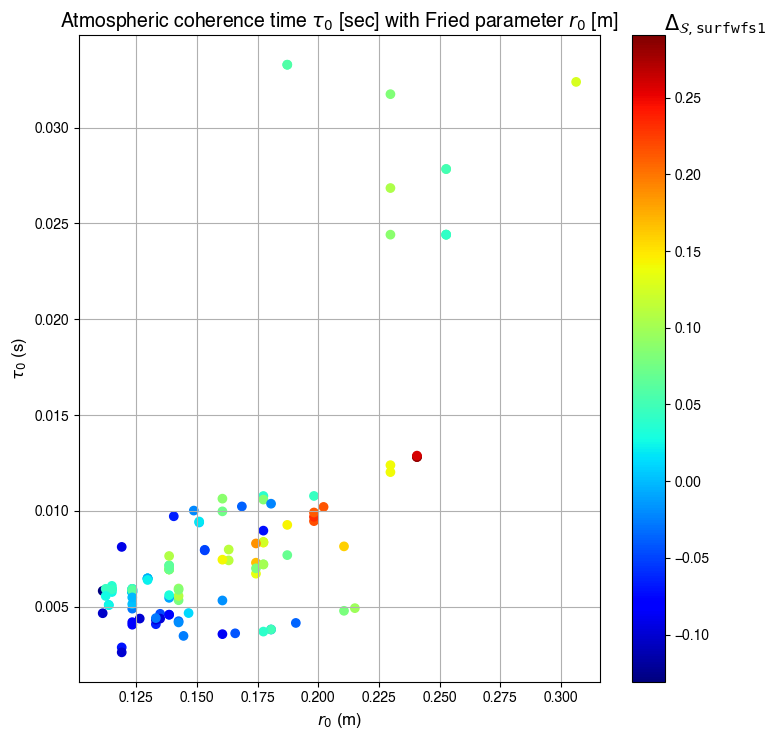

In [172]:
fig, axes = plt.subplots(figsize=(7.5, 7.5))
plt.scatter(surfwfs1_for_plotting['r0'], surfwfs1_for_plotting['tau0'], c=surfwfs1_for_plotting['delta_strehl_surfwfs1'], cmap=plt.cm.jet)
plt.title(r"Atmospheric coherence time $\tau_{0}$ [sec] with Fried parameter $r_{0}$ [m]", fontsize=14)
# plt.axline((0, 0), (1, 1), linewidth=1, color='black', linestyle="--")
plt.xlabel("$r_{0}$ (m)", fontsize=12)
plt.ylabel(r"$\tau_{0}$ (s)", fontsize=12)
plt.tight_layout()
plt.grid(True)
cbar = plt.colorbar()
cbar.set_label(r'$\Delta_{\mathcal{S}, \mathtt{surfwfs1}}$', rotation=0, y=1.035, fontsize=15)
plt.show()

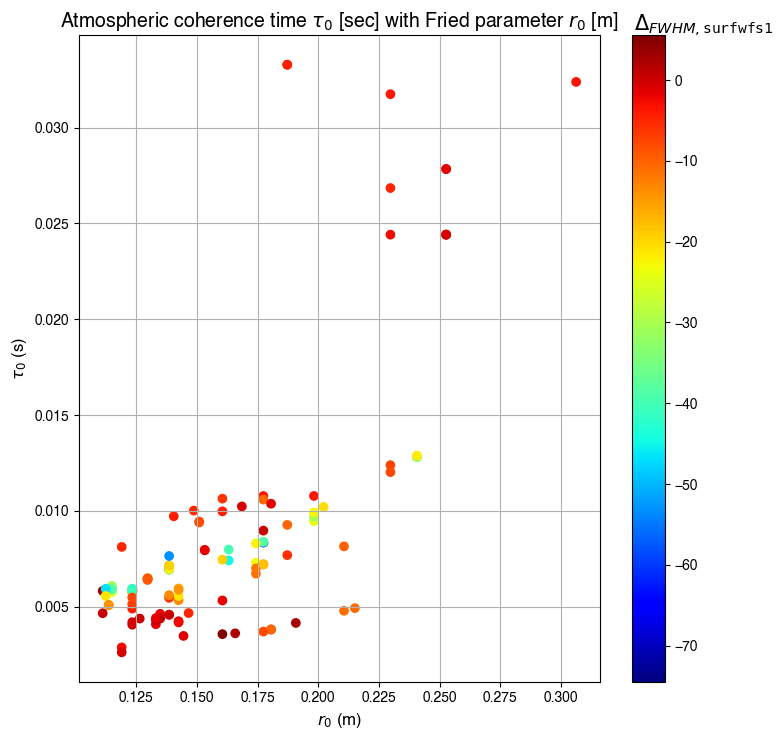

In [173]:
fig, axes = plt.subplots(figsize=(7.5, 7.5))
plt.scatter(surfwfs1_for_plotting['r0'], surfwfs1_for_plotting['tau0'], c=surfwfs1_for_plotting['delta_fwhm_surfwfs1'], cmap=plt.cm.jet)
plt.title(r"Atmospheric coherence time $\tau_{0}$ [sec] with Fried parameter $r_{0}$ [m]", fontsize=14)
# plt.axline((0, 0), (1, 1), linewidth=1, color='black', linestyle="--")
plt.xlabel("$r_{0}$ (m)", fontsize=12)
plt.ylabel(r"$\tau_{0}$ (s)", fontsize=12)
plt.tight_layout()
plt.grid(True)
cbar = plt.colorbar()
cbar.set_label(r'$\Delta_{FWHM, \mathtt{surfwfs1}}$', rotation=0, y=1.035, fontsize=15)
plt.show()